# This notebook regroups the code around graph formation/estimation -AKM estimator with MF at one dimension-

This a notebook has been initially written by Arthur Sabre and has been thereafter improved by Vincent Gimenes

Ce Notebook a pour but d'étudier le clustering de patients et de docteurs dans des embeddings générés par l'entrainement de modèle à partir de graphes bipartis. Notez bien qu'ici, la notion d'embedding et d'effet fixe seront confondus. Dans la suite, $\alpha_{i}$ fera référence à l'effet fixe (ou embedding) du patient $i$ parmis les $I$ patients tandis que $\psi_{j}$ fera référence à l'effet fixe du docteur $j$ parmi les $J$ docteurs. $X_{ij}$ désignera des features comme l'age ou le sexe du patient et du docteur. Pour garder un certain de niveau généralité, $X_p$ désignera une variable continue pour les patients, $X_d$ une variable continue pour les docteurs, $D_p$ une  variable binaire pour les patients, $D_d$ une variable binaire pour les docteurs, et nous nous ne soucierons pas de leur interprétation économique.  Cela contiendra également la distance entre le patient et le docteur. 

## Terminologie

Certains termes seront utilisés de manière interchangeable :  
- Les notions d’**embedding** et d’**effet fixe** renverront à la même idée.  
- Le terme effet fixe sera généralement employé dans le cadre de la génération, tandis que le terme embedding sera préféré dans le cadre de l’estimation, mais ce n'est pas un règle figée.

Par ailleurs, les notations `α` et `ψ` désigneront respectivement les effets fixes des patients et des docteurs. Lorsqu’un accent circonflexe (chapeau, ^) sera ajouté au-dessus de ces symboles, il fera référence à l’estimation des embeddings dans le modèle, ou à l’estimation des effets fixes.

## Packages and Import

In [3]:
#!pip install seaborn
#!pip install pandas
#!pip install matplotlib
#!pip install scikit-learn
#!pip install pillow
#!pip install umap-learn

In [59]:
# bibliothéques fondamentales
import matplotlib.pyplot as plt
import pandas as pd
#import bipartitepandas as bpd
import numpy as np
import time
import random
pd.options.mode.chained_assignment = None  # default='warn' # Remove copy on slice warning

# Pour faire du ML/DL
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn import preprocessing

from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
from sklearn.preprocessing import LabelEncoder
simplefilter("ignore", category=ConvergenceWarning) # Useful for logistic regression

from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dot, Embedding, Add, Flatten, Activation, Layer, Concatenate, Dense # Optimisation via tensorflow.keras
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import Callback
pd.options.mode.chained_assignment = None  # default='warn' # Remove copy on slice warning
import tensorflow as tf
from keras import regularizers
from sklearn.metrics import precision_score, recall_score, f1_score, mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # Confusion Matrix

# Pour visualisation
from sklearn.decomposition import PCA
import umap.umap_ as umap
import seaborn as sns

# Clustering
from sklearn.cluster import KMeans, DBSCAN, MeanShift
from sklearn.mixture import GaussianMixture
from sklearn import metrics

# Pour stocker un tuple
import pickle

# Pour calcul de similarité entre les matrices
from numpy.linalg import norm
from sklearn.metrics.pairwise import cosine_similarity

# Afficher un cercle autour d'un point
import matplotlib.patches as patches

# Pour rafraichir les scripts des modules sans redémarrer le kernel
import importlib

# Pour compter le temps d'exécution d'une fonction
import time

sns.set_theme(style = "whitegrid")

In [42]:
# module maison
import script.decorateur as decorateur
import script.graph_formation as graph_formation
import script.MF_NRS as MF_NRS
import script.simulation as simulation
import script.metrique as metrique
import script.animation as animation
import script.plot_functions as plot_functions

# importe la classe directement
GraphFormation = graph_formation.GraphFormation
get_estimations = MF_NRS.get_estimations

# Recharge les modules (A executer en cas de modification des scripts, cela permet d'éviter de restart le kernel)
importlib.reload(decorateur)
importlib.reload(graph_formation)
importlib.reload(MF_NRS)
importlib.reload(simulation)
importlib.reload(metrique)
importlib.reload(animation)
importlib.reload(plot_functions)

<module 'script.plot_functions' from '/home/onyxia/work/G4H_AKM_RS_NRS/script/plot_functions.py'>

## Formation du graphe avec AKM (1D)

Comme les stagiaires n'ont pas accès au données santé (confidentialité), il faut travailler sur des données simulées. Pour ce faire, dans les cellules suivantes, la fonction génère un graphe biparti entre des patients et des docteurs dont les liens $Y_{ij}$ (vaut 1 s'il y a un lien entre i et j, 0 sinon) suivent un modèle AKM, c'est-à-dire la loi suivante:

$$P(Y_{ij} = 1 | X_{ij}) = (1 + e^{-T})^{-1}$$         
où    $T = \alpha_{i} + \psi_{j} + X_{ij}\beta$ 

Dans la suite, nous générerons le graphe avec ces paramètres fixés:

- une feature continue (dans le sens que la variable n'est pas catégorielle) pour le patient (l'age par exemple)
- une feature continue pour le docteur (exemple: l'age également)
- une feature binaire  pour le patient (exemple: le patient utilise internet/doctolib ou non )
- une feature binaire pour le docteur (exemple: le docteur a certaines compétences ou non)
- une feature distance, qui a pour valeur simplement la distance entre le patient et le docteur. Les patients et les docteurs seront placés aléatoirement par des lois uniformes sur un carré [0,1] x [0,1]

- Le nombre de patients sera fixé à 1000 et le nombre de docteur sera fixé à 50. Ces nombres ont été choisis arbitrairement de façon à avoir (i) une asymétrie de taille entre les patients et les docteurs marquées, et donc réaliste, (ii) un nombre assez conséquent d'observations pour garantir des résultats statistiques significatif, (iii) un nombre pas trop important d'observations pour gagner du temps de calcul, notamment lorsque des centaines de simulations sont effectuées.

In [35]:
graph_object= GraphFormation(
                    n_patients=1000,
                     n_doctors=50,
                     max_number_connections=50,
                    beta_distance_graph = -25,)
graph_object.do_the_graph()
print(f"density of the graph: {graph_object.density*100:.2f}%")

density of the graph: 9.69%


La cellule suivante concerne le modèle d'entrainement. Ce modèle est un dérivé des modèles de Matrix Factorization, qui sont initialement utilisés pour les systèmes de recommandations. 
L'architecture de notre modèle est tel que les inputs (patient id , docteur id, features entre patient et docteur):
- passent respectivement par un embedding pour les patients avec un output de dimension 1, un embedding (en parallèle) pour les docteurs avec un output de dimension 1 et enfin une multiplication par un paramètre beta (pour les features).
- puis les résultats sont additionnés
- et enfin la somme passe par une fonction d'activation, une sigmoïde.

Mathématiquement, cela donne: $(i, j, X_{ij}) \mapsto \sigma(\alpha_{i} +  \psi_{j} + X_{ij})$. Les paramètres d'entrainements du modèle sont donc ceux des embeddings et le beta. Ces paramètres sont optimisés par Keras par descente de gradient classique.

In [44]:
# Training
estimates = get_estimations(graph_object.df, nb_epochs=40, show_print=0, learning_rate=0.003)

# Recuperation des poids au niveau des embeddings
ef_patient_hat = estimates[1][0]
ef_doctor_hat = estimates[1][1]

# Recuperation des poids pour les beta
beta_X_p_hat = estimates[1][2]
beta_X_d_hat = estimates[1][3]
beta_D_p_hat = estimates[1][4]
beta_D_d_hat = estimates[1][5]
beta_distance_hat = estimates[1][6]

# Recuperation de l'objet "model"
model = estimates[4]

## Etudes Préléminaires

### Etude de la qualité de prédiction du modèle MF (1D)

La fonction suivante divise les données en ensembles d'entraînement et de test, entraîne un modèle sur l'ensemble d'entraînement et évalue sa performance sur l'ensemble de test. Elle trace l'historique de l'entraînement, la matrice de confusion et imprime diverses métriques de performance telles que la précision, le rappel, le F1-score et l'erreur quadratique moyenne. La fonction imprime également les coefficients estimés (bêtas) et leurs erreurs par rapportaux paramètres réels de l'objet graph_object.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Mean Squared Error sur l'échantillon de test : 0.2820354472358063
Precision: 0.82
Recall: 0.74
F1-score: 0.78
ESTIMATION BETA: X p [0.26039737]; X d [0.05314287]; D_p [1.4708217]; D_d [3.845038]; distance [-22.43536]
ERROR ESTIMATION BETA: X p [0.06039737]; X d [-0.14685714]; D_p [0.47082174]; D_d [2.845038]; distance [2.56464]


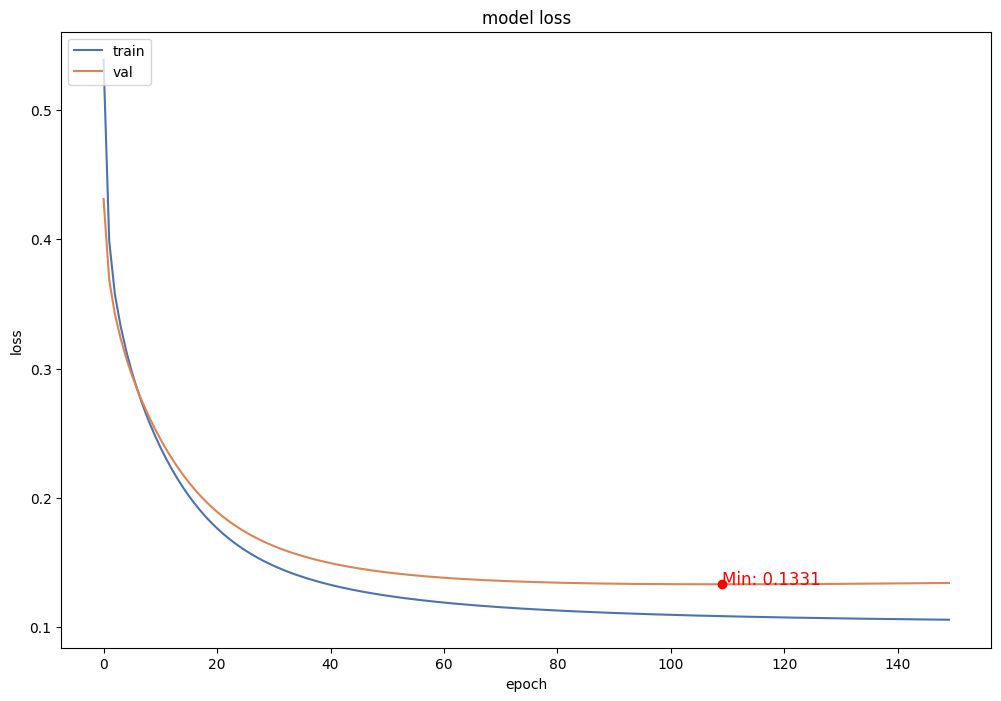

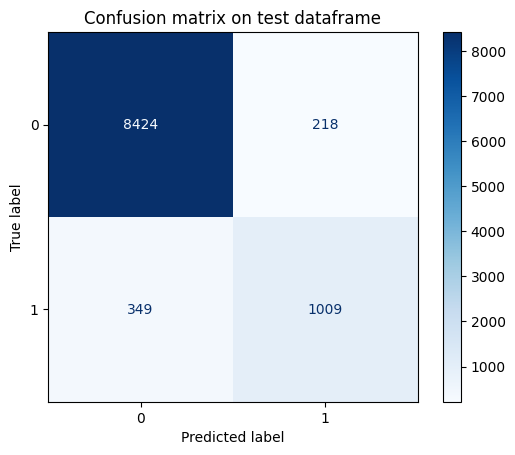

Temps d'exécution : 106 secondes


In [204]:
MF_NRS.prediction_score(graph_object, nb_epochs=150)

affichage de la matrice de confusion: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

<span style="color:blue">**CONCLUSION:**</span> Nous pouvons constater que le modèle apprend plutôt bien, dans le sens où il prédit assez correctement les liens sur le jeu de test, bien que les classes de labels soient très désiquilibrées (90% de 0). Cela se remarque par les cases en en haut à droite et en bas à gauche qui sont équilibrées et le recall qui est élevé.

### Etude de l'évolution de loss et du RMSE à travers les epoques

Les cellules précédentes semblent montrer qu'il est inutile d'entrainer le modèle plus de 120 epochs. Le but des cellules suivantes est de vérifier si cela reste vrai même lorsque la densité du graphe est bien différente.
La fonction suivante simule des graphes pour chaque valeur de beta_distance dans `sim_beta_distance_array`.
Pour chaque graphe simulé, elle calcule la densité du graphe, affiche cette densité, et entraîne un modèle
avec les données du graphe en utilisant `prediction_score`. Cela permet de comparer les courbes de loss et les minimums.

In [213]:
MF_NRS.loss_vs_density(sim_beta_distance_array = [-25,-17, -13,-10, -8, -5,-3], nb_epochs=140)

density of the graph: 13.60%


KeyboardInterrupt: 

Par lecture graphique, il semblerait que le nombre d'epochs nécessaire avant d'atteindre le minimum sur la fonction de loss sur le jeu de validation diminue à mesure que la densité du graphe augmente. 
La fonction suivante trace l'évolution de l'erreur quadratique moyenne (RMSE) des effets fixes à travers les époques pour différentes valeurs de densité (qui varie via la variation du beta_distance). Cela nous permettra d'avoir une idée de comment le RMSE varie à travers les epoques, selon la densité du graphe. Nous pourrons alors avoir une idée du nombre d'époques idéal.

Le RMSE des effets fixes est défini par:

$ RSME_{\alpha,\psi} =   [ \frac{1}{JI}  \sum_{i,j}  (\alpha_{i}^{*} + \psi_{j}^{*} - \hat{\alpha_{i}} - \hat{\psi_{j}})^{2}   ]^{\frac{1}{2}}   $

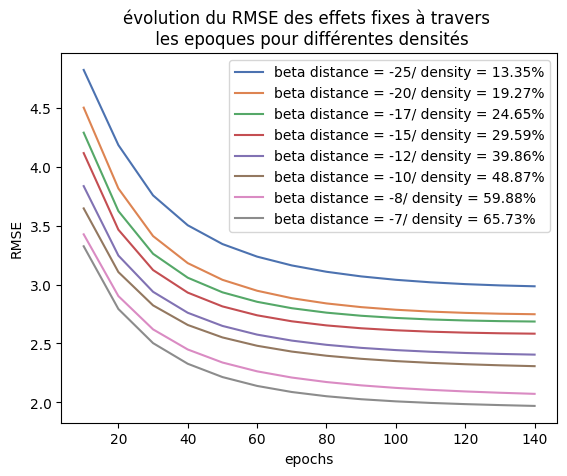

Temps d'exécution : 1654 secondes


In [212]:
# Temps d'exécution : 1827 secondes
density_ami_rmse_simulation.plot_rmse_epochs(n=14, save=True)

Il semble que même avec un nombre d'époques élevées, nous n'avons pas réussi à atteindre un plateau pour le RMSE. Réessayons pour une seule valeur de beta, mais avec 250 epoques:

[4.90420166 4.38907076 3.96931369 3.69492178 3.51373158 3.38793879
 3.29665503 3.22821384 3.17569393 3.13473624 3.10243496 3.07678079
 3.05632972 3.04001838 3.02704051 3.01678143 3.0087612  3.00259448
 2.99797884 2.99466384 2.99245099 2.99117763 2.99070634 2.99092002
 2.99172535]
[ 10  20  30  40  50  60  70  80  90 100 110 120 130 140 150 160 170 180
 190 200 210 220 230 240 250]


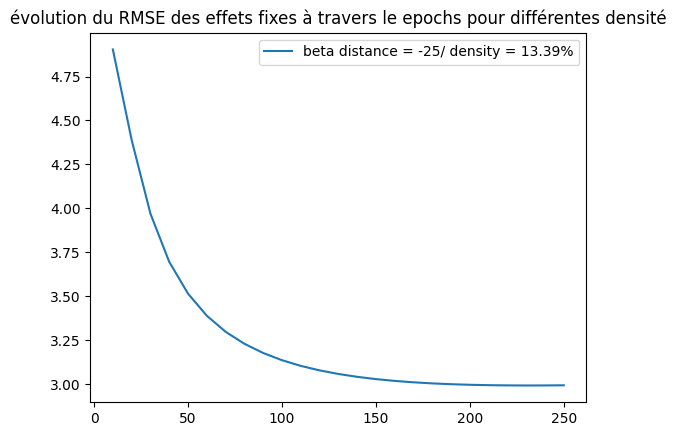

Temps d'exécution : 411 secondes


In [26]:
# Temps d'exécution : 411 secondes
density_ami_rmse_simulation.plot_rmse_epochs(n = 25, sim_beta_distance_array = [-25], save=True)

<span style="color:blue">**CONCLUSION:**</span> (voir image RMSE_vs_epochs_density.png") Nous constatons que quelque soit la densité du graphe, le RMSE continue de décroître, même après 140 époques. Il faudrait environ 200 epoques aux modèles pour arriver sur un plancher en terme de RMSE. Remarquons également qu'une plus grande densité du graphe conduit de façon clair à un RMSE plus faible. 

### Etude estimation des betas

Nous allons maintenant étudier l'estimation des beta par le modèle. Pour ce faire, nous allons créer 100 graphes différents (mais avec les mêmes paramètres par défault) et estimer les betas. Si nous obtenons des distrubtions normales centrée en la vraie valeur de beta pour les betas estimés, nous pourrons conclure que le modèle estime bien les betas

In [ ]:
simulation_beta.simulation_beta(n=100, nb_epochs=140)

Simulation 1: done !
Simulation 2: done !
Simulation 3: done !
Simulation 4: done !
Simulation 5: done !
Simulation 6: done !
Simulation 7: done !
Simulation 8: done !
Simulation 9: done !
Simulation 10: done !
Simulation 11: done !
Simulation 12: done !
Simulation 13: done !
Simulation 14: done !
Simulation 15: done !
Simulation 16: done !
Simulation 17: done !
Simulation 18: done !
Simulation 19: done !


<span style="color:blue">**CONCLUSION:**</span> (voir image "Simulation_estimation_beta.png") Nous pouvons constater que les betas des variables continues X patient et X docteur sont très bien estimés. En revanche, les betas des variables binaires sont surestimés, voire très surestimé pour la variable D docteur. Il y a également un biais non négligeable pour le beta distance. L'estimation des betas par le modèle est plutôt moyenne/mauvaise. Cependant, notre analyse portera désormais exclusivement sur l'estimation des effets fixes et non plus sur les beta.

### Etude du paramètre de régularization L2 pour l'embedding

Nous allons maintenant étudier la régularization l2 sur l'embedding. Quel va être le lambda optimal pour minimiser le RMSE? C'est à cette question que nous allons tenter de répondre.

In [50]:
array1 = [10**(-i) for i in range(3,11)]
array2 = [2*10**(-i) for i in range(3,11)]
l = np.sort(np.concatenate((array1, array2)))

In [ ]:
simulation_regularization.plot_rmse_lambda(regu_lambdas = l, nb_epochs=200)

Simulation 1: done !
Simulation 2: done !
Simulation 3: done !
Simulation 4: done !
Simulation 5: done !
Simulation 6: done !
Simulation 7: done !


<span style="color:blue">**CONCLUSION:**</span> L'effet de la régularization semble négative sur le RMSE global. Il me semble préférable de ne pas mettre de régularization.

## Etude de la qualité du clustering 

Maintenant que nous savons un peu près quel lambda de régularisation et quel nombre d'epochs sont optimales pour minimiser le RMSE, nous allons nous concentrer sur une autre métrique. En effet, en cross section, il va être très difficile d'estimer les effets fixes de façon précise, voire impossible. C'est pourquoi le RMSE restera globalement haut et qu'il n'est pas vraiment possible de le réduire encore plus. Heuresement pour nous, nous ne voulons pas estimer exactement les effets fixes, mais simplement retrouver les classes de patients/doceurs, soit les clusters initiaux, ce qui est une tache relativement plus simple.  

Comme nous avons générer notre graphe, nous savons comment les effets fixes ont été attribué, notament la classe des agents (attributs alpha_class et psi_class de graph_object). En lançant des algorithmes de clustering comme un k-means sur les EF estimés par le modèle et en récupérant les labels attribués sur ces mêmes EF par les algorithmes, nous allons pouvoir analyser si oui ou non, des algorithmes de clusterings sont capables de retrouver les bonnes classes parmi nos patients/docteurs. Cette qualité de clustering sera quantifié grâce à la métrique Adjusted Mutal Information (AMI). 

Le "Adjusted Mutual Information score" qui est une version ajustée du "Mutual Information score" afin de ramener à 0 le score pour un clustering aléatoire. Le Mutual Information score est une mesure de la similartité entre deux "labels" du même jeu de données.
Soient $|U_{i}|$ le nombre d'observations dans le cluster (ou la classe) $U_{i}$ et $|V_{j}|$ le nombre d'observations dans le cluster. Le Mutual Information socre entre les deux partitions de clusters $U$ et $V$ est donnée  par l'expression suivante:

$MI(U,V) = \sum_{i} \sum_{j} \frac{|U_{i} \cap V_{j}|}{N}log \frac{N|U_{i} \cap V_{j}|}{|U_{i}| |V_{j}|}$

où $N$ est le nombre total d'observations 

Notons que la métrique est symétrique et indépendante de toute permutation entre les clusters (le label 0, 1, 2 ou même n'importe quoi sur tel ou tel cluster n'a pas d'importance)

L'Ajusted Mutual Information est donné par la formule:

$ AMI(U, V) = \frac{MI(U, V) - E(MI(U, V))}{avg(H(U), H(V)) - E(MI(U, V))} $

où $H(.)$ est l'entropie, dont l'expression est $H(U) := - \sum_{i=1}^{R} \frac{|U_{i}|}{N} log \frac{|U_{i}|}{N}$

Source pour plus de détails:

https://en.wikipedia.org/wiki/Adjusted_mutual_information
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_mutual_info_score.html#sklearn.metrics.adjusted_mutual_info_score
https://jmlr.csail.mit.edu/papers/volume11/vinh10a/vinh10a.pdf

Lors de la formation de notre graphe, nous avons créer 3 classes différentes un peu près équilibrées pour les patients et docteurs. Ces différences de classe sont traduites directement dans les effets fixes; puisque les effets fixes suivent, par défaut, les distributions suivantes:

$\alpha_{i} \sim \lambda_{\alpha} ( \omega_{1, \alpha}\delta_{0} + \omega_{2, \alpha}\delta_{1} + \omega_{3, \alpha}\delta_{2})$

$\psi_{j} \sim \lambda_{\psi} ( \omega_{1, \psi}\delta_{0} + \omega_{2, \psi}\delta_{1} + \omega_{3, \psi}\delta_{2})$

où $\delta_{x}$ désigne une loi de dirac en x et $\lambda_{\alpha}$ (respectivement $\lambda_{\psi}$) un paramètre de dilatation des EF pour les patients (respectivement les docteurs). Ce paramètre est fixé à 2 par défaut. Dans notre graphe par défaut, les EF sont donc espacés de 2. Les paramètres $\omega$ sont les poids attribués à chaque classe. Ces poids sont par défaut de l'ordre de 0.3/0.3/0.4.

Dans les paramètres du graphe (voir module graph_formation), il est possible de changer les diracs en normales. Mais il est préférable de commencer par des diracs pour rendre les choses plus simples et moins bruités.

Notre but va être de retrouver combien de classe y a t-il (le plus dur), puis de bien retrouver la classe d'appartenance des agents via les algorithmes de clustering. Le fait de bien retrouver les classes ou non sera mesuré par la métrique AMI décrite plus haut

### Visualisation

La visualisation sera un outil essentiel pour la détection de cluster, notamment pour déterminer le nombre de classe qu'il existe parmi les patients/docteurs. Elle le sera d'autant plus lorsque nous passerons en dimension supérieur pour les EF.
La visualisation pour les EF star donc du mélange de dirac étant assez inutile, nous allons directement visualiser les EF estimés par notre modèle après 200 epochs (semble optimal pour minimiser le RMSE) sans regularisation, sur notre graphe par défaut (densité autour de 13%):

In [19]:
graph_object= GraphFormation(
                    n_patients=1000,
                     n_doctors=50,
                     max_number_connections=50,
                    beta_distance_graph = -25,)
graph_object.do_the_graph()
graph_object.density

0.13318

In [20]:
# temps d'execution pour l'entrainement: 283

# Training
estimates = get_estimations(graph_object.df, nb_epochs=120, show_print=0, show_time_execution=1,)
# Recuperation des EF  
ef_patient_hat = estimates[1][0]
ef_doctor_hat = estimates[1][1]

temps d'execution pour l'entrainement: 211


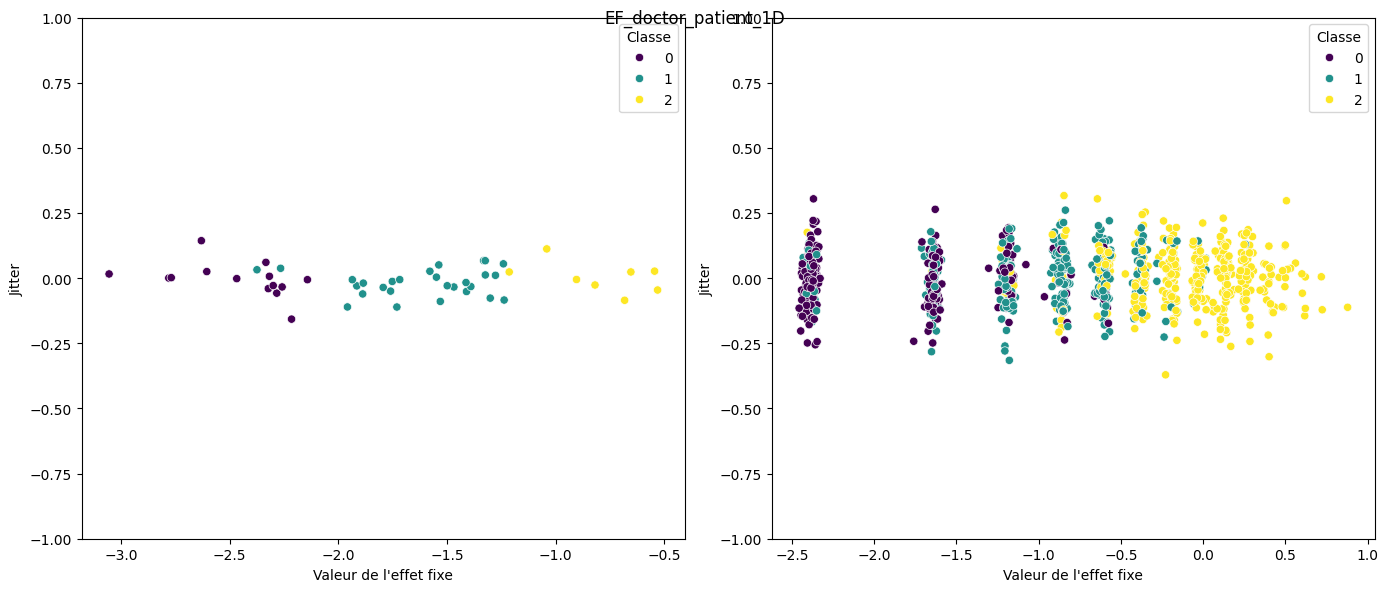

In [46]:
plot_functions.plot_ef_1D(graph_object, ef_patient = ef_patient_hat, ef_doctor = ef_doctor_hat, save=False)

Pour les patients, on n'observe pas de cluster clairement apparent. En revanche, les couleurs nous indique que le modèle a assez bien identifié les classes dans cette masse.

Les cellules suivantes représentent les histogrammes des degrés des patients et des docteurs. D'abord de l'ensemble des agents, puis avec une distinction de couleur selon la classe. Cela nous permet de voir un peu près combien d'agents ont combien de liens.

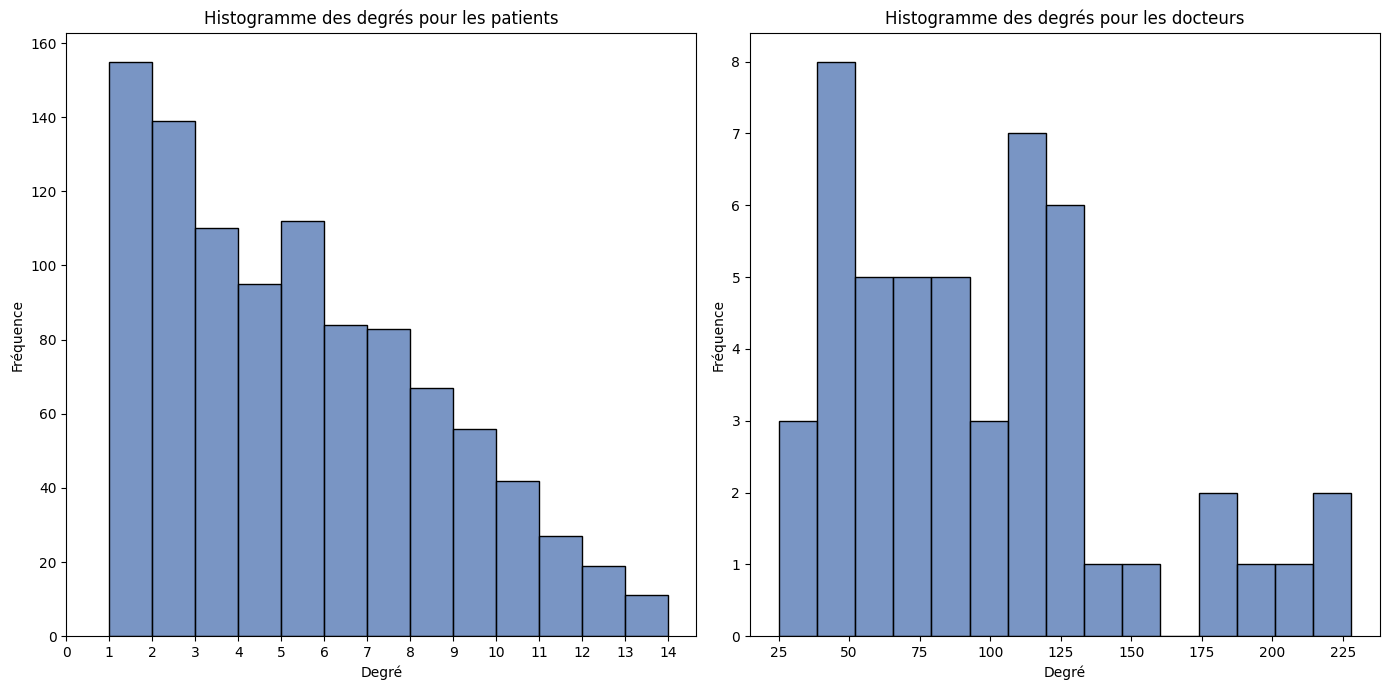

In [17]:
# Affiche l'histogramme des degrés
plot_functions.plot_hist_degree(graph_object, hue_class = False, save = False)

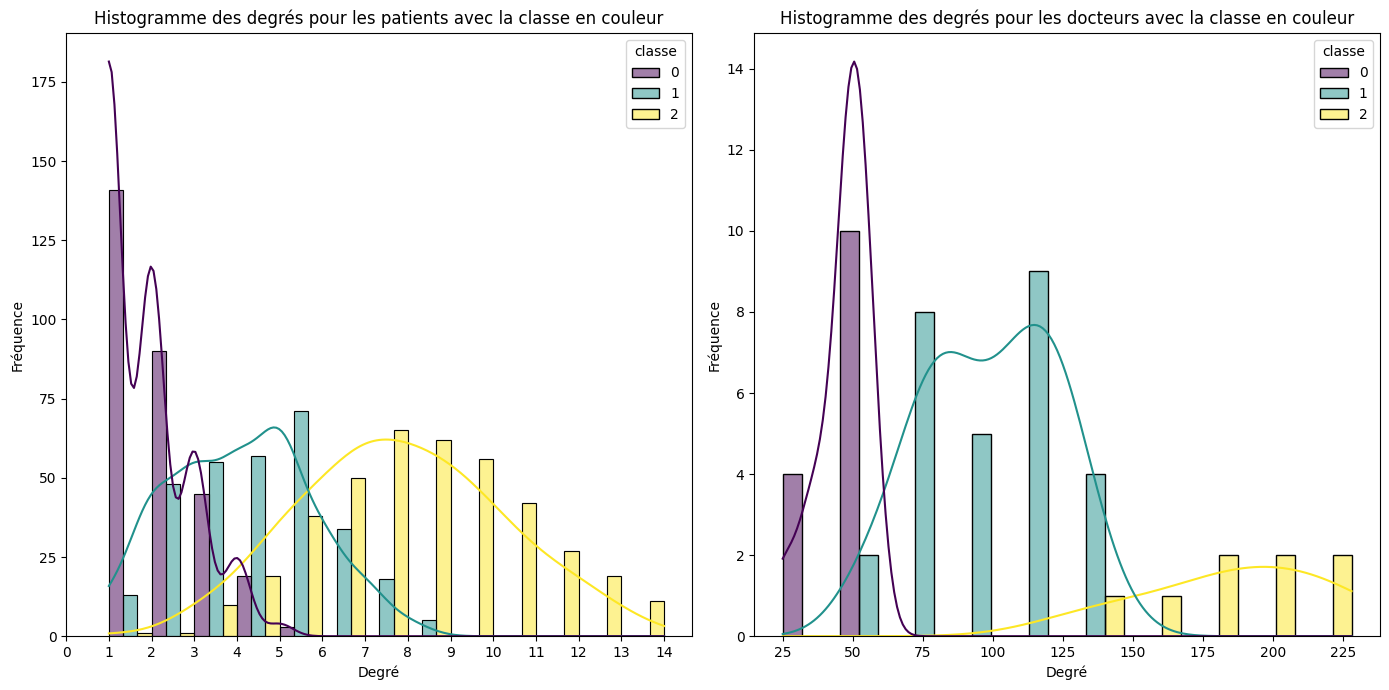

In [18]:
# Affiche l'histogramme des degrés par classe
plot_functions.plot_hist_degree(graph_object, hue_class = True, save = False)

### Clustering, AMI et visualisation

Observons maintenant le clustering estimé par un algorithme K-means avec $k=3$ (Nous faisons comme ci nous connaissions à l'avance le nombre de classe). Nous pouvons mesurer cette estimation avec l'AMI:

In [19]:
# K-means sur les docterus avec K = 6
kmeans_d_hat = KMeans(n_clusters=6, random_state=1)
kmeans_d_hat.fit(ef_doctor_hat.reshape(-1,1))
cluster_doctor_hat = kmeans_d_hat.labels_

# K-means sur les patients avec K = 3
kmeans_p_hat = KMeans(n_clusters=3, random_state=2) 
kmeans_p_hat.fit(ef_patient_hat.reshape(-1,1))
cluster_patient_hat = kmeans_p_hat.labels_

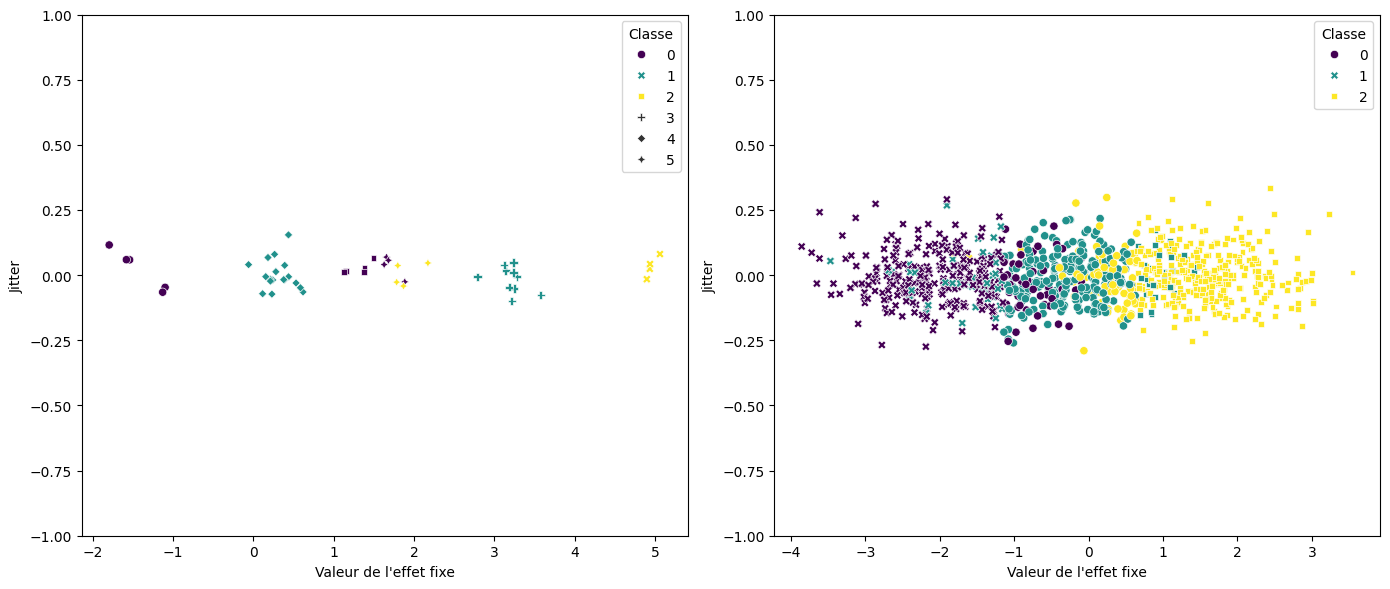

In [20]:
plot_functions.plot_ef_1D(graph_object, ef_patient = ef_patient_hat, ef_doctor = ef_doctor_hat, style_d = cluster_doctor_hat, style_p = cluster_patient_hat, title = None)

In [18]:
metric_doctor_hat =  metrics.adjusted_rand_score(graph_object.psi_class, cluster_doctor_hat)
print(f"AMI du clustering sur l'embedding estimé des docteurs: {metric_doctor_hat}")
metric_patient_hat =   metrics.adjusted_rand_score(graph_object.alpha_class, cluster_patient_hat)
print(f"AMI du clustering sur l'embedding estimé des patients: {metric_patient_hat}")

AMI du clustering sur l'embedding estimé des docteurs: 0.5369740956484454
AMI du clustering sur l'embedding estimé des patients: 0.5951435685177048


<span style="color:blue">**CONCLUSION:**</span> La détermination des clusters parmis les patients et les docteurs semble moyenne pour notre graphe par défaut. Les AMI retournent des scores plutôt moyens bien que pas complétement médiocres.

#### Inertie, elbow effet et AMI

In [17]:
tab_kmeans = metrique.tab_ami_kmeans_inertia(graph_object, ef_patient=ef_patient_hat, ef_doctor = ef_doctor_hat, return_ = True)

    K  Inertia patient  AMI patient  Inertia doctor  AMI doctor
0   2       690.478394     0.479513       46.001167    0.149014
1   3       322.545319     0.615136       26.706491    0.262891
2   4       206.677231     0.437282       16.661570    0.303070
3   5       131.607834     0.398765        3.104495    0.490652
4   6       103.161232     0.363408        2.722020    0.399853
5   7        69.661888     0.331375        1.262916    0.442004
6   8        58.199909     0.283106        1.045278    0.315887
7   9        45.810829     0.254112        0.982009    0.307292
8  10        37.437668     0.246905        0.640698    0.281361


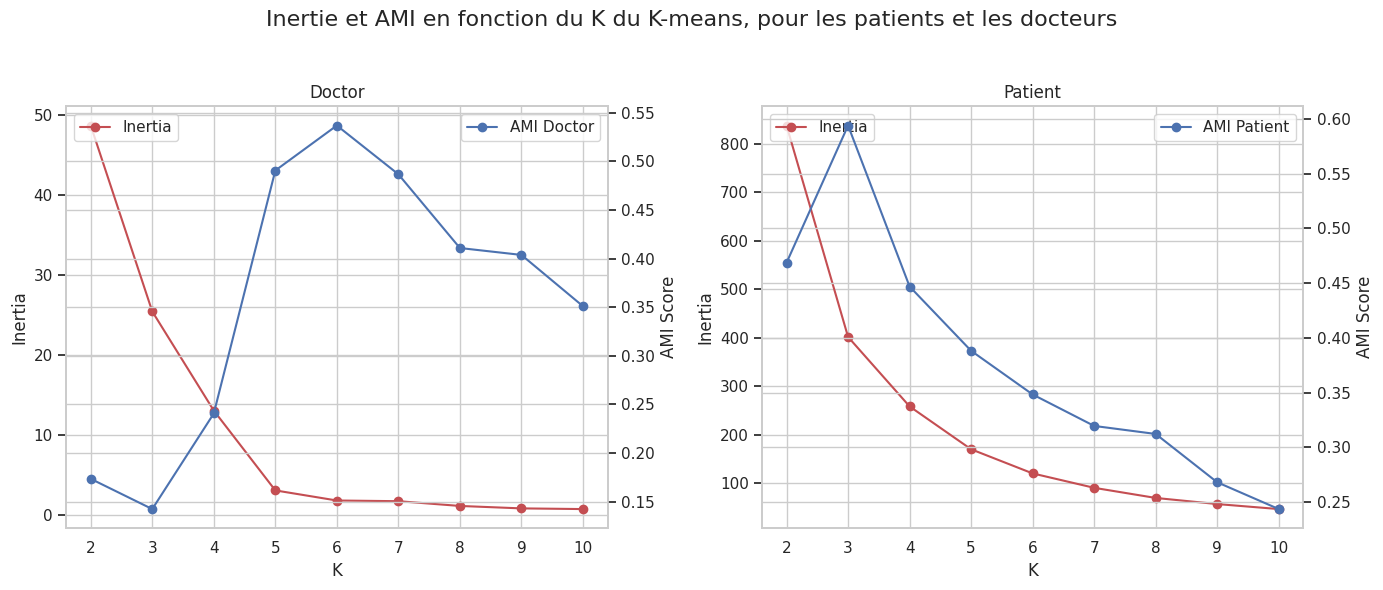

In [35]:
plot_functions.plot_tab_ami_inertia_kmeans(tab_kmeans)

### AMI vs density

Nous allons maintenant étudier l'AMI du clustering en fonction de la densité du graphe. Pour ce faire, nous allons tracer l'AMI évaluée à 7 ou 8 niveaux de densité différentes (en faisant varier le beta distance), et cela 100 fois pour obtenir un intervalle de confiance. Notez bine qu'ici, les EF seront exactement les mêmes pour tous les graphes. Les liens, l'entrainement, et le clustering seront en revanche légérement différents d'une simulation à l'autre.

In [ ]:
matrix_sim_ami = density_ami_rmse_simulation.simulation_density_ami(n=100, sim_beta_distance_array = [-25, -20,-15, -12, -10,-8,-5, -3,], nb_epochs=200, n_patients = 1000, n_doctors=50)
with open('matrix_simulation_ami.npy', 'wb') as f:
    np.save(f, matrix_sim_ami)

In [6]:
with open('Simulations/matrix_simulation_ami.npy', 'rb') as f:
    matrix_simulation_ami = np.load(f)

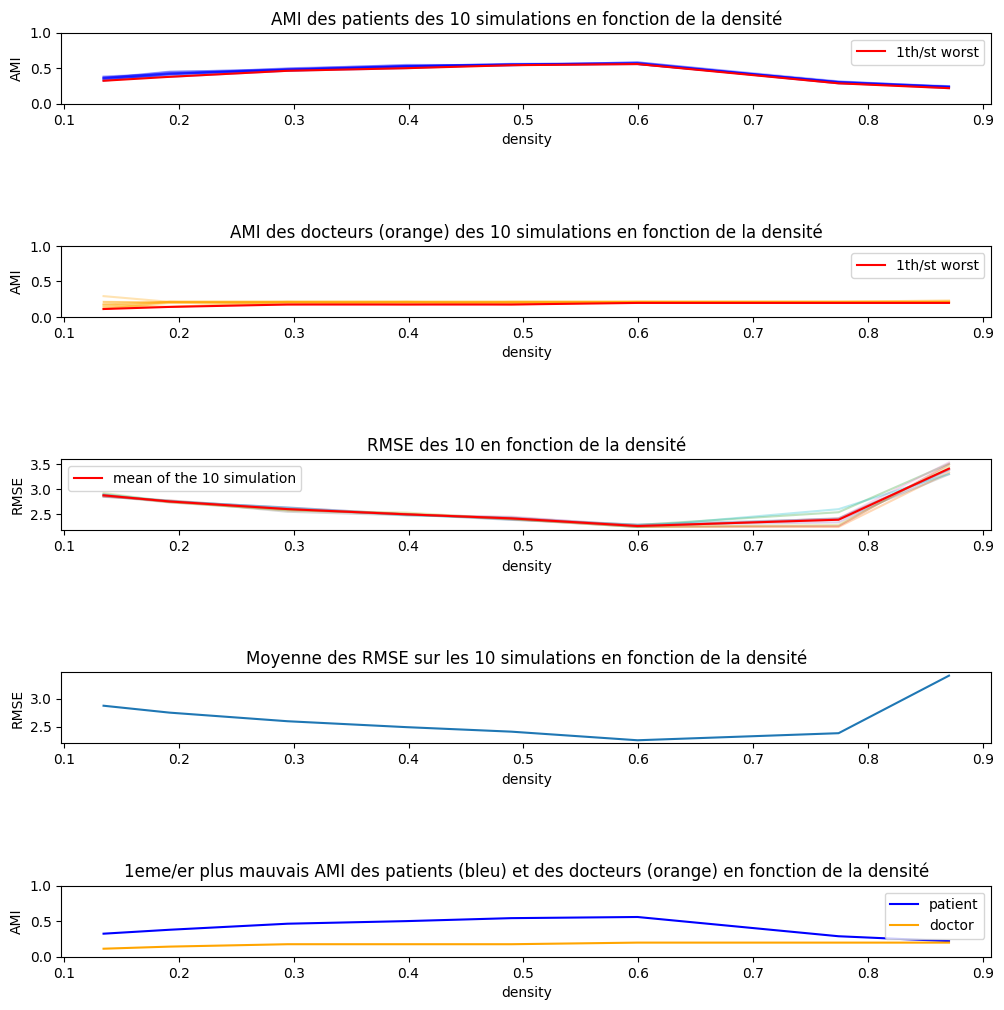

In [11]:
plot_functions.plot_simulation_density_ami(matrix_simulation_ami,rank=8, n=10)

In [355]:
matrix_sim_ami_k6d = density_ami_rmse_simulation.simulation_density_ami(n=10, sim_beta_distance_array = [-25, -20,-15, -12, -10,-8,-5, -3,], nb_epochs=200, n_patients = 1000, n_doctors=50, n_clusters_d = 6)
with open('matrix_simulation_ami_k6d.npy', 'wb') as f:
    np.save(f, matrix_sim_ami_k6d)

KeyboardInterrupt: 

In [ ]:
with open('Simulations/matrix_simulation_ami_k6d.npy', 'rb') as f:
    matrix_simulation_ami = np.load(f)

In [ ]:
plot_funtions.plot_simulation_density_ami(matrix_simulation_ami,rank=8, n=10)

Faisons maintenant la même expérience mais pour un graphe biparti équilibré, c'est-à-dire avec le même nombre de patients et de docteurs.

In [ ]:
matrix_sim_ami_sym = density_ami_rmse_simulation.simulation_density_ami(n=10, sim_beta_distance_array =[-25, -20,-15, -12, -10,-8,-5, -3,], nb_epochs=200, n_patients = 100, n_doctors=100)
with open('matrix_simulation_ami_symmetric.npy', 'wb') as f:
    np.save(f, matrix_sim_ami_sym)

In [320]:
with open('Simulations/matrix_simulation_ami_symetric.npy', 'rb') as f:
    matrix_simulation_ami_sym = np.load(f)

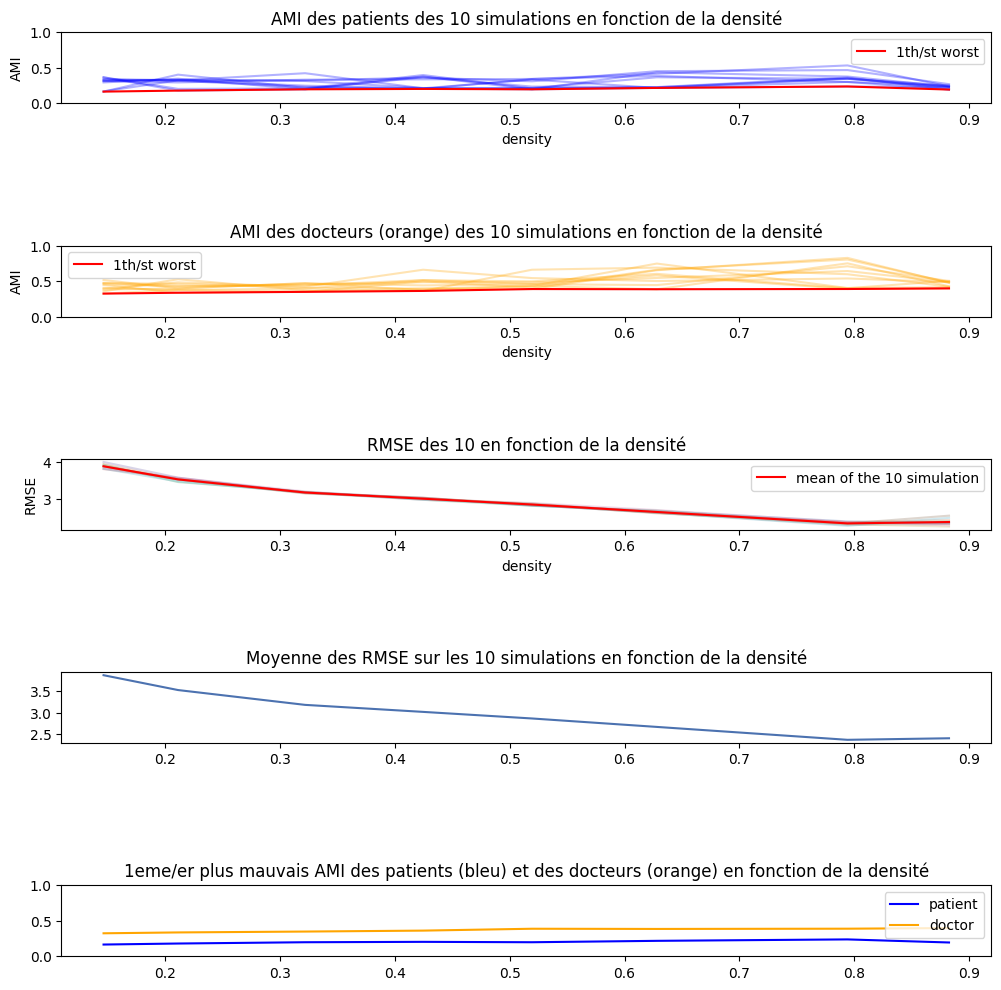

In [332]:
plot_functions.plot_simulation_density_ami(matrix_simulation_ami_sym,rank=8, n=10, save=True)

<span style="color:blue">**CONCLUSION:**</span> Les EF restent stables pour la simulation du graphe symétrique, ce qui n'est pas exacatement le cas de celui asymétrique. On remarque également qu'il y a très peu de variance pour les courbes d'AMI pour le graphe asymétrique alors qu'il y en a un peu plus pour le graphe symétrique. Il y a pas beaucoup de résultats qui apparaissent clairement.

### AMI et coefficient de dilatation

Nous allons désormais étudier l'évolution de l'AMI en fonction des coefficients de dilatation des EF. On peut s'attendre à ce que plus, ils augmentent, plus les EF seront distincts et meilleur sera le clustering. 

#### Dilatation sur les patients et les docteurs

In [6]:
matrix_sim_dila = density_ami_rmse_simulation.simulation_ami_dilatation(n=10, sim_dilatation_array = [0.1, 0.5, 1, 2, 3, 4, 5, 6], sim_beta_distance_array = np.ones(8)*(-25), nb_epochs=200)
with open('matrix_simulation_dilatation.npy', 'wb') as f:
    np.save(f, matrix_sim_dila)

NameError: name 'density_ami_rmse_simulation' is not defined

In [7]:
with open('Simulations/matrix_simulation_dilatation.npy', 'rb') as f:
    matrix_simulation_dilatation = np.load(f)

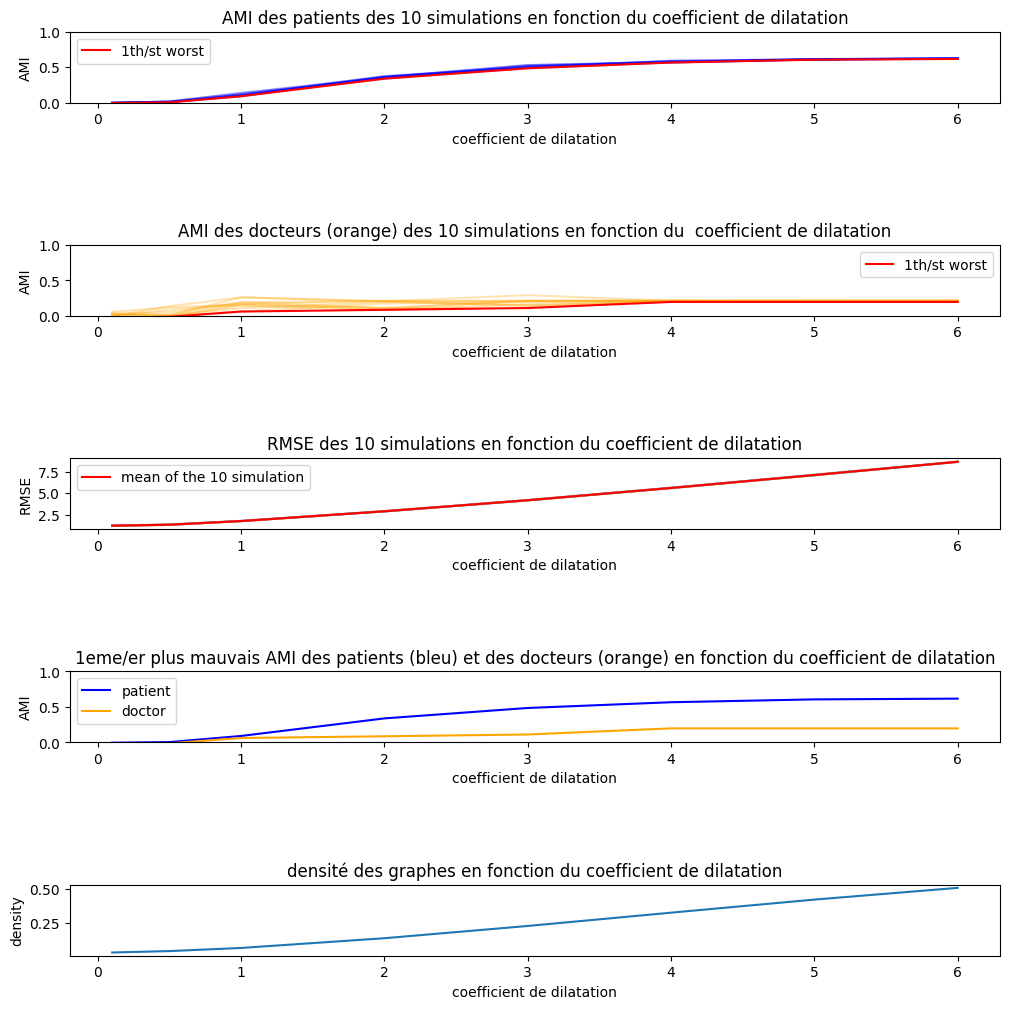

In [17]:
plot_functions.plot_simulation_dilatation_ami(matrix_simulation_dilatation,
                                                                dilatation_array=[0.1, 0.5, 1, 2, 3, 4, 5, 6], 
                                                                n=10, 
                                                                worst=1,
                                                                save=True
                                                                )

On observe que l'AMI des patients a très peu de variance entre les simulations et  que la métrique augmente significativement avec le coefficient de dilatation (de 0 à 0.5). L'AMI des docteurs a peu plus de variance par endroit entre les simulations et la métrique augmente également avec le coefficient de dilatation, mais bien plus légerement.

#### Dilatation sur les patients seulement

In [ ]:
matrix_simulation_dilatation_only_p = density_ami_rmse_simulation.simulation_ami_dilatation(n=10, 
                                                  patient_dilatation = True,
                                                  doctor_dilatation = False, 
                                                  sim_dilatation_array = [0.2, 0.5, 1, 2, 3, 4, 5, 6], 
                                                  sim_beta_distance_array = np.ones(8)*(-25),
                                                  nb_epochs=200,
                                                  n_patients=1000, n_doctors=50 )

with open('matrix_simulation_dilatation_only_p.npy', 'wb') as f:
    np.save(f, matrix_simulation_dilatation_only_p)

In [389]:
with open('Simulations/matrix_simulation_dilatation_only_p.npy', 'rb') as f:
    matrix_simulation_dilatation_only_p = np.load(f)

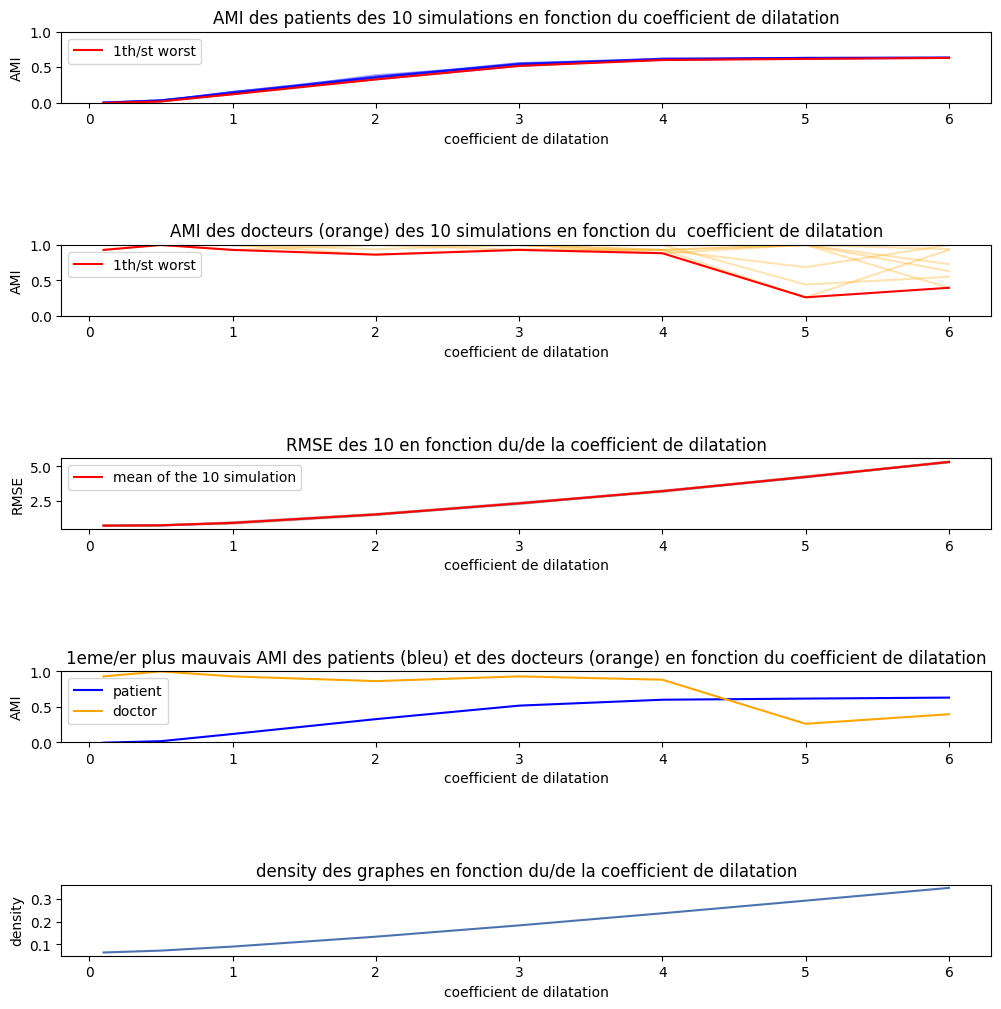

In [395]:
plot_functions.plot_simulation_dilatation_ami(matrix_simulation_dilatation_only_p,
                                                                dilatation_array=[0.1, 0.5, 1, 2, 3, 4, 5, 6], 
                                                                n=10, 
                                                                worst=1,
                                                               )

#### Dilatation sur les docteurs seulement

In [ ]:
matrix_simulation_dilatation_only_d = density_ami_rmse_simulation.simulation_ami_dilatation(n=10, 
                                                  patient_dilatation = False,
                                                  doctor_dilatation = True, 
                                                  sim_dilatation_array = [0.2, 0.5, 1, 2, 3, 4, 5, 6], 
                                                  sim_beta_distance_array = np.ones(8)*(-25),
                                                  nb_epochs=200,
                                                  n_patients=1000, n_doctors=50 )
with open('matrix_simulation_dilatation_only_d.npy', 'wb') as f:
    np.save(f, matrix_simulation_dilatation_only_d)

In [398]:
with open('Simulations/matrix_simulation_dilatation_only_d.npy', 'rb') as f:
    matrix_simulation_dilatation_only_d = np.load(f)

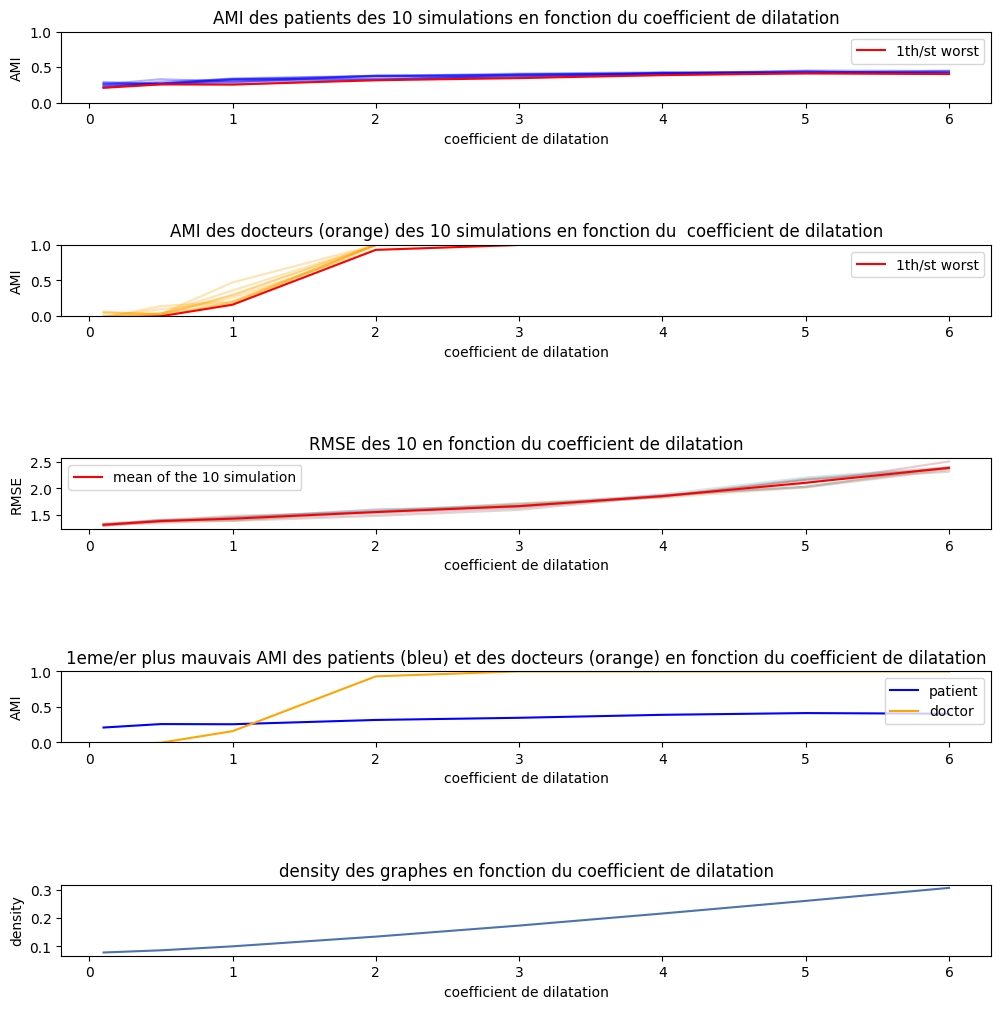

In [412]:
plot_functions.plot_simulation_dilatation_ami(matrix_simulation_dilatation_only_d,
                                                                dilatation_array=[0.1, 0.5, 1, 2, 3, 4, 5, 6], 
                                                                n=10, 
                                                                worst=1, 
                                                                save=True
                                                               )

#### Dilatation avec ajustement de la densité par le beta distance

Nous allons maintenant ajuster le beta distance pour amaintenir la densité au même niveau, peu importe le niveau de dilatation. Dans la configuration suivante, les beta distance sont choisis de façon à garder une densité autour de 13%. 

In [ ]:
matrix_simulation_dilatation_adjusted = density_ami_rmse_simulation.simulation_ami_dilatation(n=10, 
                                                  patient_dilatation = True,
                                                  doctor_dilatation = True, 
                                                  sim_dilatation_array = [0.2, 0.5, 1, 2, 3, 4, 5, 6], 
                                                  sim_beta_distance_array = [-9, -11, -15, -25, -35, -45, -55, -65] ,
                                                  nb_epochs=200,
                                                  n_patients=1000, n_doctors=50 )
with open('matrix_simulation_dilatation_adjusted.npy', 'wb') as f:
    np.save(f, matrix_simulation_dilatation_adjusted)

In [414]:
with open('Simulations/matrix_simulation_dilatation_adjusted.npy', 'rb') as f:
    matrix_simulation_dilatation_adjusted = np.load(f)

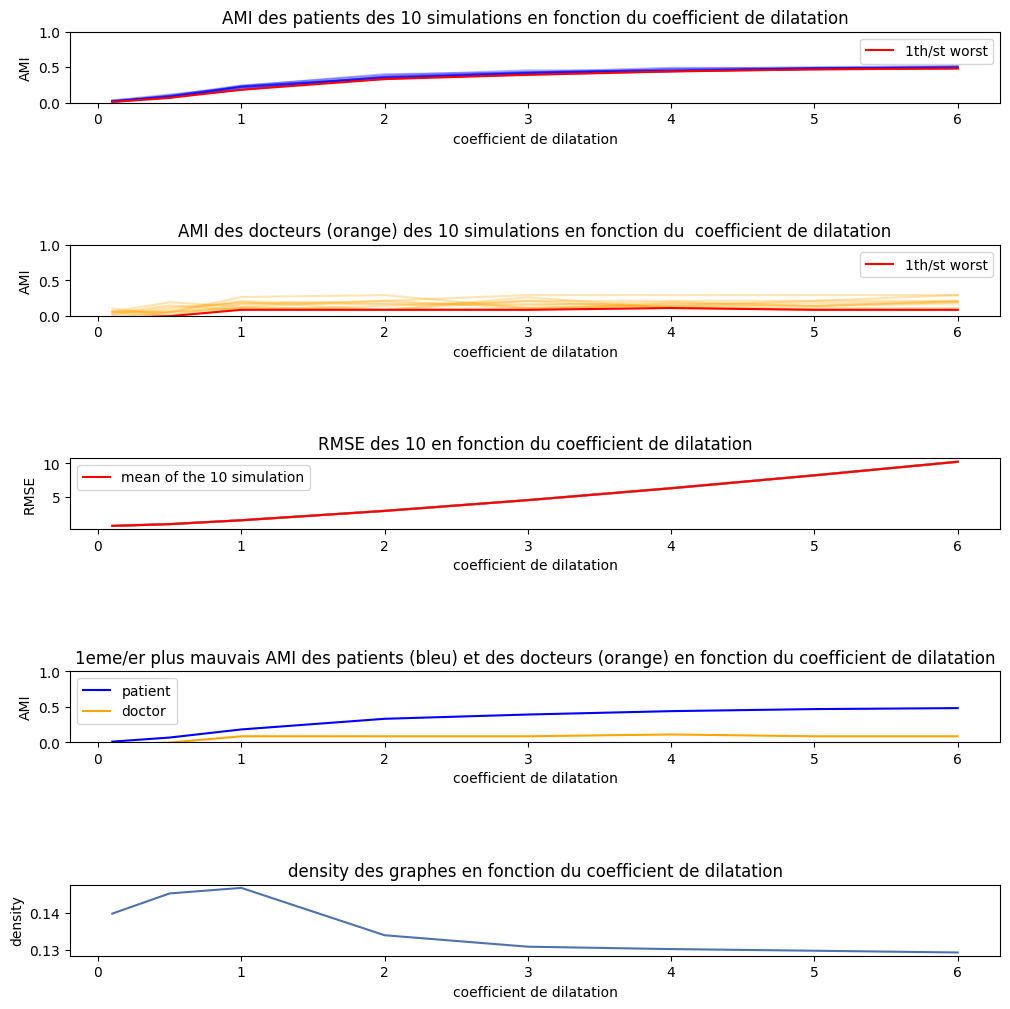

In [417]:
plot_functions.plot_simulation_dilatation_ami(matrix_simulation_dilatation_adjusted,
                                                                dilatation_array=[0.1, 0.5, 1, 2, 3, 4, 5, 6], 
                                                                n=10, 
                                                                worst=1,
                                                                
                                                               )

#### AMI et coefficient de régularisation

Simulation 1: done !
Simulation 2: done !
Simulation 3: done !
Simulation 4: done !
Simulation 5: done !
Simulation 6: done !
Simulation 7: done !


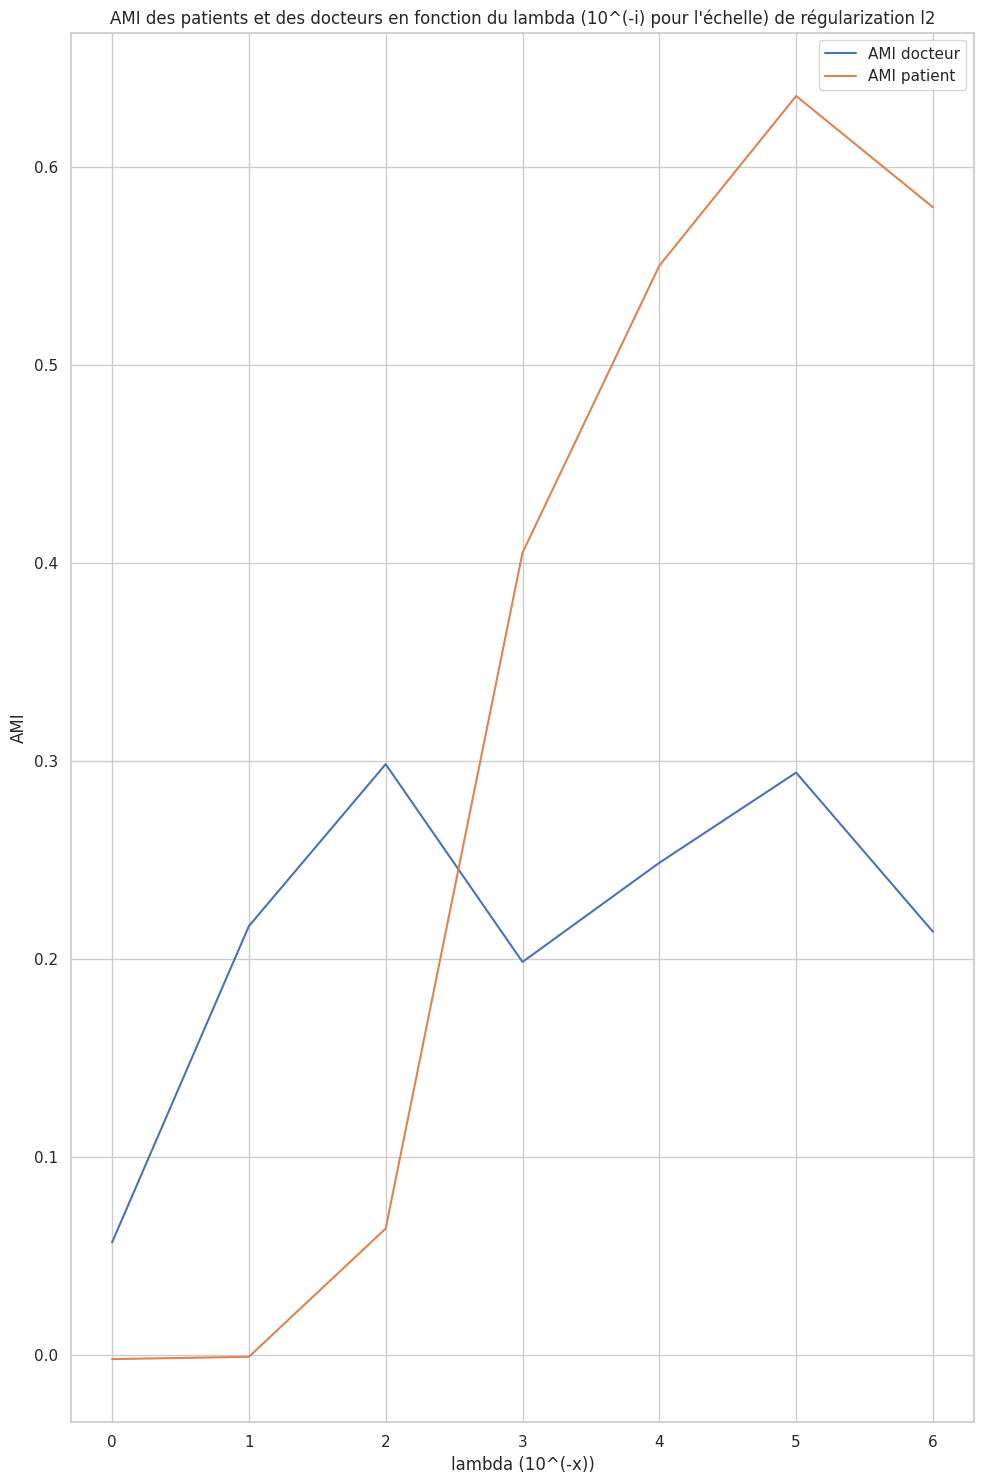

In [61]:
simulation.simulation_ami_lambda( regu_lambdas = np.array([10**(-i) for i in range(7)]), nb_epochs=120, save=True, algorithm = "MF" )

Le graphique nous confirme que la régularisation L2 sur l'embedding n'est pas bénéfique.

### Robustesse

Pour Evaluer la robustesse de l'embedding estimé, nous allons, 100 fois, prendre 80% des data aléatoirement et les fournir au modèle. Ensuite, pour chaque simulation nous construisons une matrice des distances euclidiennes $A_{k}$ où la composante $a_{ij}$ vaut la distance euclidienne entre $\alpha_{i}$ et $\alpha_{j}$ (ou entre $\psi_{i}$ et $\psi_{j}$).
Puis, nous formons un nouvelle matrice B de taille 100 x 100 où la composante $b_{ij}$ vaut la cosine similarity entre les matrices $A_{i}$ et $A_{j}$. Enfin, nous prenons la moyenne pour avoir une idée de la robustesse.

In [ ]:
simulation.robustesse_all(100, 0.8, graph_object, nb_epochs = 140, dim_embedding = 1,  algorithm = "MF")

simulation 1: done


### Essais avec d'autres algorithmes que le k-means

J'ai utilisé d'autres méthodes de clustering pour tester.

#### Gaussian Mixture Models

In [134]:
graph_object= GraphFormation(
                    n_patients=1000,
                     n_doctors=50,
                     max_number_connections=50,
                    beta_distance_graph = -25,)
graph_object.do_the_graph()

# temps d'execution pour l'entrainement: 210
# Training
estimates = get_estimations(graph_object.df, nb_epochs=200, show_print=0, show_time_execution=1,)
# Recuperation des EF  
ef_patient_hat = estimates[1][0]
ef_doctor_hat = estimates[1][1]

temps d'execution pour l'entrainement: 153


In [135]:
ef_patient_hat = ef_patient_hat.flatten()
ef_doctor_hat = ef_doctor_hat.flatten()

In [179]:
# Initialiser le modèle KMeans avec 4 clusters
gmm_d = GaussianMixture(n_components=3, random_state=1)
# Ajuster le modèle sur les données
gmm_d.fit(ef_doctor_hat.reshape(-1, 1))
# On retire les labels attribués
cluster_doctor_hat = gmm_d.predict(ef_doctor_hat.reshape(-1, 1))

# Initialiser le modèle KMeans avec 4 clusters
gmm_p = GaussianMixture(n_components=3, random_state=2)
gmm_p.fit(ef_patient_hat.reshape(-1, 1))
# Ajuster le modèle sur les données
gmm_p.fit(ef_patient_hat.reshape(-1,1))
# On retire les labels attribués
cluster_patient_hat = gmm_p.predict(ef_patient_hat.reshape(-1, 1))

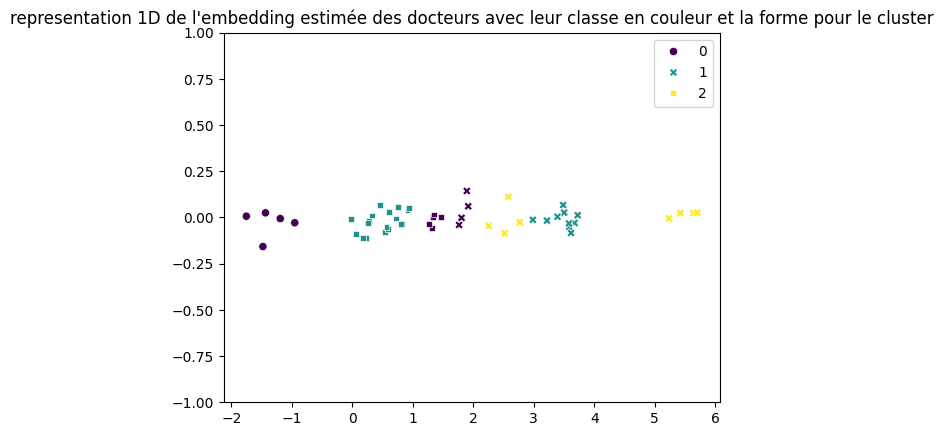

In [180]:
#Visualisation des clusters
sns.set_palette("deep") 

# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot(x= ef_doctor_hat, y= np.random.normal(0, 0.05, size= ef_doctor_hat.shape[0],), hue=graph_object.psi_class, style=cluster_doctor_hat, palette='viridis')
plt.title("representation 1D de l'embedding estimée des docteurs avec leur classe en couleur et la forme pour le cluster")
plt.ylim(-1,1)
plt.show()

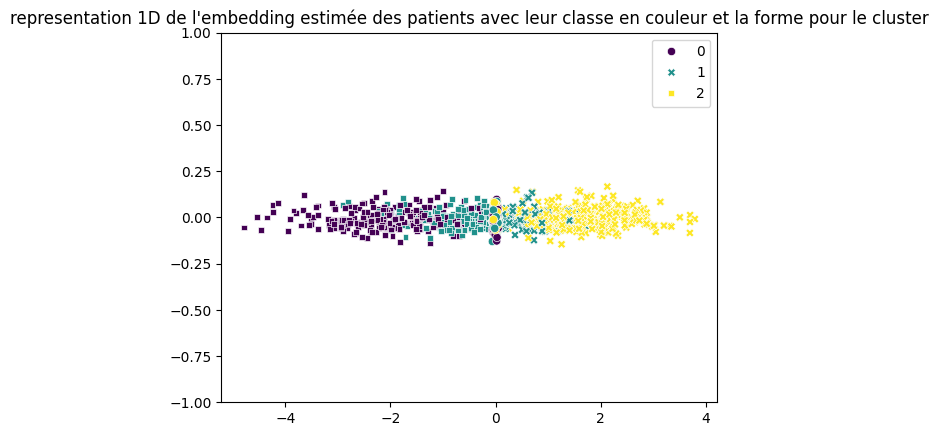

In [183]:
#Visualisation des clusters
sns.set_palette("deep") 

# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot(x= ef_patient_hat, y= np.random.normal(0, 0.05, size= ef_patient_hat.shape[0],), hue=graph_object.alpha_class, style=cluster_patient_hat, palette='viridis')
plt.title("representation 1D de l'embedding estimée des patients avec leur classe en couleur et la forme pour le cluster")
plt.ylim(-1,1)
plt.show()

In [184]:
metric_doctor_hat =  metrics.adjusted_rand_score(graph_object.psi_class, cluster_doctor_hat)
print(f"AMI du clustering sur l'embedding estimé des docteurs: {metric_doctor_hat}")
metric_patient_hat =   metrics.adjusted_rand_score(graph_object.alpha_class, cluster_patient_hat)
print(f"AMI du clustering sur l'embedding estimé des patients: {metric_patient_hat}")

AMI du clustering sur l'embedding estimé des docteurs: 0.1747920640607299
AMI du clustering sur l'embedding estimé des patients: 0.3596044460765202


#### Mean Shift

In [140]:
# Appliquer Mean Shift
mean_shift_d = MeanShift()  # Vous pouvez ajuster le paramètre 'bandwidth'
mean_shift_d.fit(ef_doctor_hat.reshape(-1, 1))
cluster_doctor_hat = mean_shift_d.labels_

In [141]:
# Appliquer Mean Shift
mean_shift_p = MeanShift()  # Vous pouvez ajuster le paramètre 'bandwidth'
mean_shift_p.fit(ef_patient_hat.reshape(-1, 1))
cluster_patient_hat = mean_shift_p.labels_

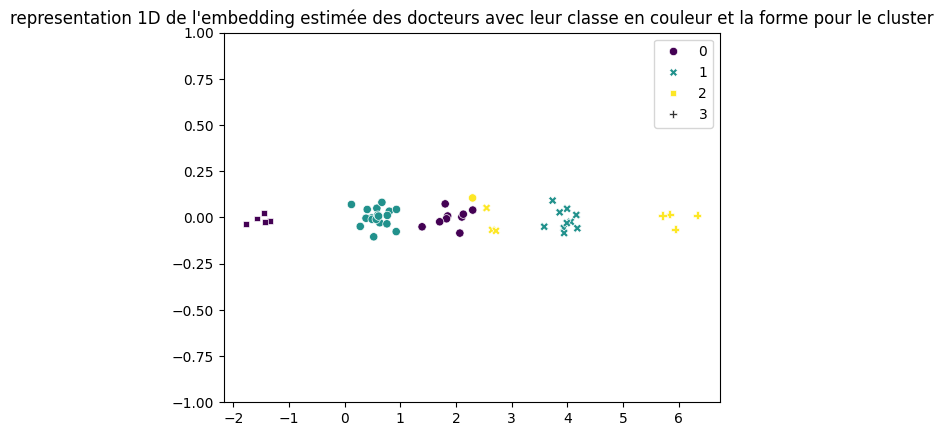

In [142]:
#Visualisation des clusters
sns.set_palette("deep") 

# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot(x= ef_doctor_hat, y= np.random.normal(0, 0.05, size= ef_doctor_hat.shape[0],), hue=graph_object.psi_class, style=cluster_doctor_hat, palette='viridis')
plt.title("representation 1D de l'embedding estimée des docteurs avec leur classe en couleur et la forme pour le cluster")
plt.ylim(-1,1)
plt.show()

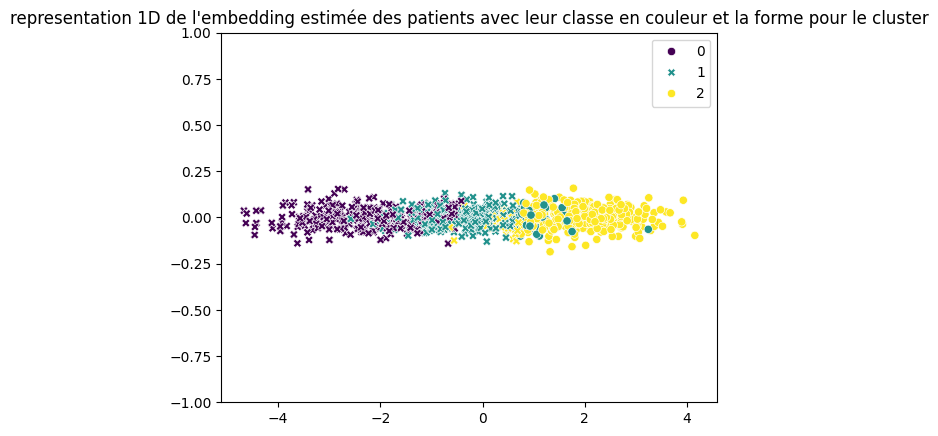

In [143]:
#Visualisation des clusters
sns.set_palette("deep") 

# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot(x= ef_patient_hat, y= np.random.normal(0, 0.05, size= ef_patient_hat.shape[0],), hue=graph_object.alpha_class, style=cluster_patient_hat, palette='viridis')
plt.title("representation 1D de l'embedding estimée des patients avec leur classe en couleur et la forme pour le cluster")
plt.ylim(-1,1)
plt.show()

In [144]:
metric_doctor_hat =  metrics.adjusted_rand_score(graph_object.psi_class, cluster_doctor_hat)
print(f"AMI du clustering sur l'embedding estimé des docteurs: {metric_doctor_hat}")
metric_patient_hat =   metrics.adjusted_rand_score(graph_object.alpha_class, cluster_patient_hat)
print(f"AMI du clustering sur l'embedding estimé des patients: {metric_patient_hat}")

AMI du clustering sur l'embedding estimé des docteurs: 0.20990531540404286
AMI du clustering sur l'embedding estimé des patients: 0.4482399862602361


## Animation

Save done


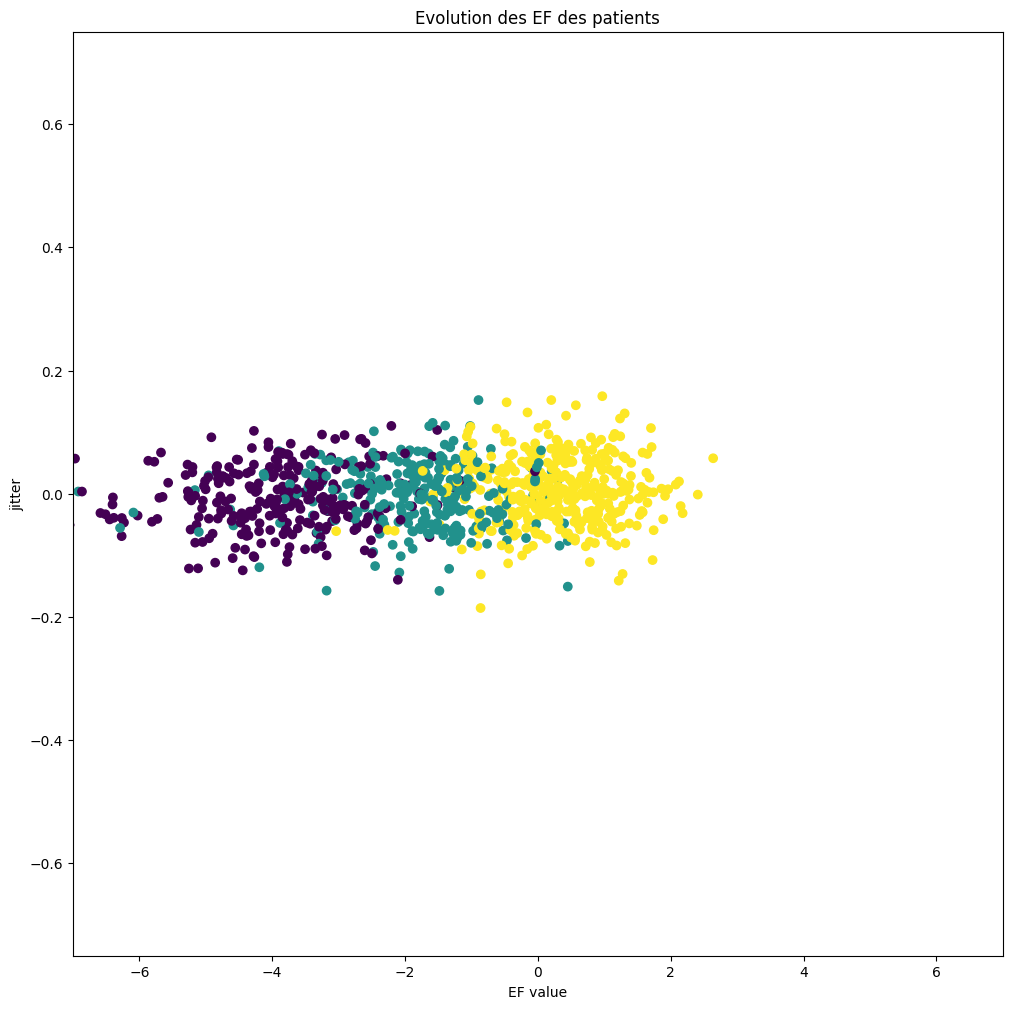

In [132]:
animation.animation_embedding_1D(graph_object, nb_epochs=200, who="patient")

Save done


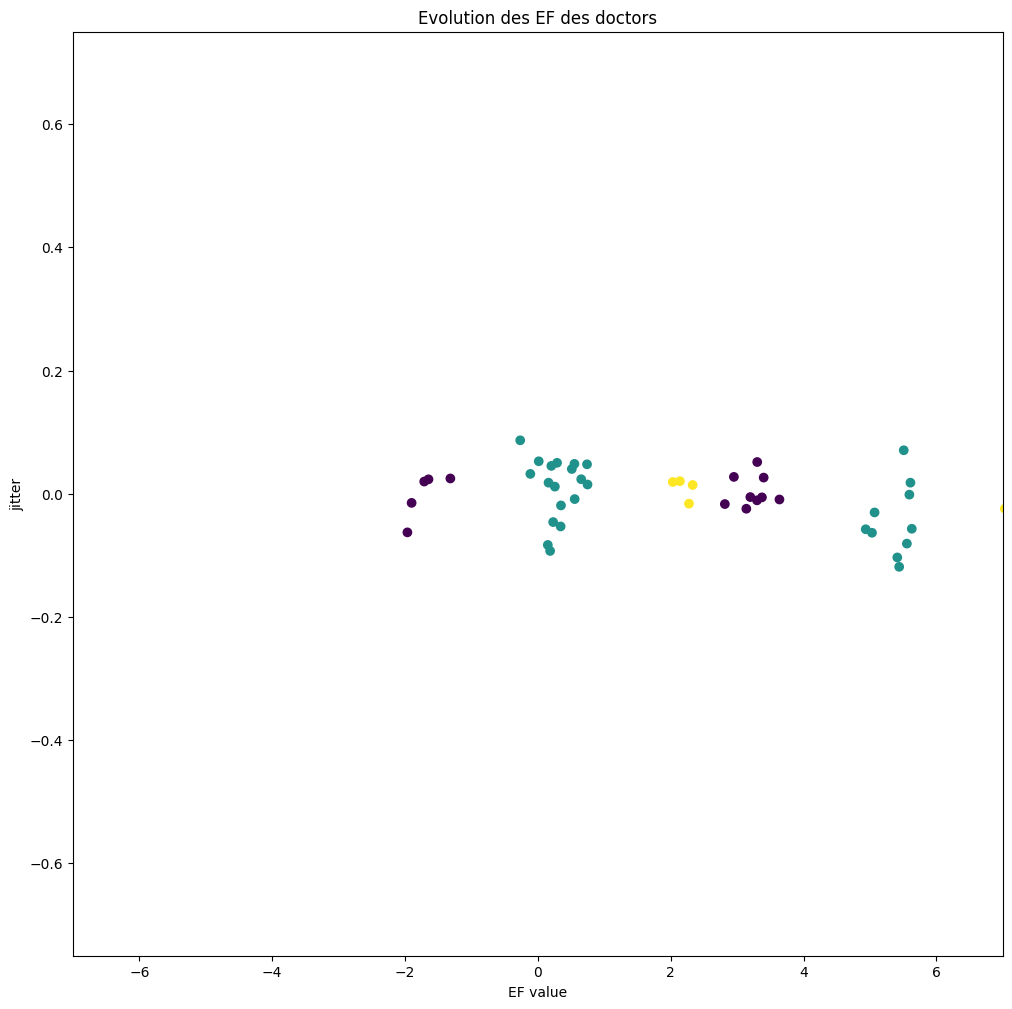

In [133]:
animation.animation_embedding_1D(graph_object, nb_epochs=200, who="doctor")

En regardant les animations, on peut remarquer 2 choses étranges: Il y a un petit nombre d'EF des patients qui restent à 0 et ne varient jamais. ( Le problème s'est réglé en mettant un validation_split plus bas voire à 0 pendant l'entrainement. il semblerait que le split soit définitif à travers les epochs, ce qui fait que certains patients ont tous leurs liens "caché" pendant l'entrainement ). Chez les docteurs, on remarque que chaque classe ce divise ensuite en deux, ce qui fait que l'on finit par obtenir presque 6 clusters au lieu de 3. Mon hypothèse est que cette différention se fait sur la variable binaire des docteurs "D_d" qui a peut-être une valeur trop élévé. 

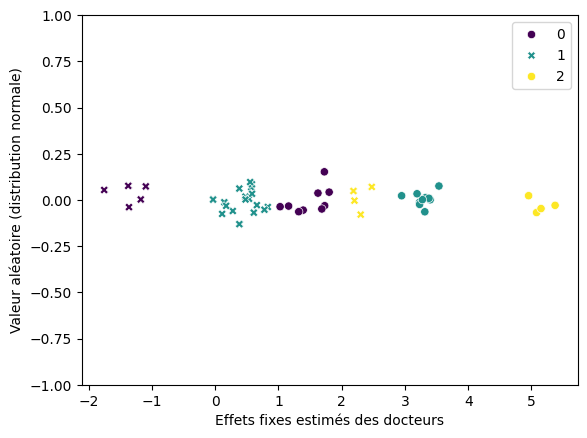

In [28]:
#Visualisation des clusters
sns.set_palette("deep") 

# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot(x= ef_doctor_hat.flatten(), y= np.random.normal(0, 0.05, size= ef_doctor_hat.flatten().shape[0],), hue=graph_object.psi_class, style=graph_object.sim_doctor_D, palette='viridis')
plt.ylim(-1,1)
# Ajouter des labels aux axes et au titre
plt.xlabel('Effets fixes estimés des docteurs')
plt.ylabel('Valeur aléatoire (distribution normale)')
#plt.title("Représentation 1D de l'embedding estimé des docteurs\n"
          #"Classe des docteurs en couleur et différence de la valeur de la feature binaire en forme")
plt.savefig("EF_doctor_feature_D")
plt.show()

Le graphe valide parfaitement notre hypothèse

Regardons maintenant si ce nous faisons la même chose pour le patient

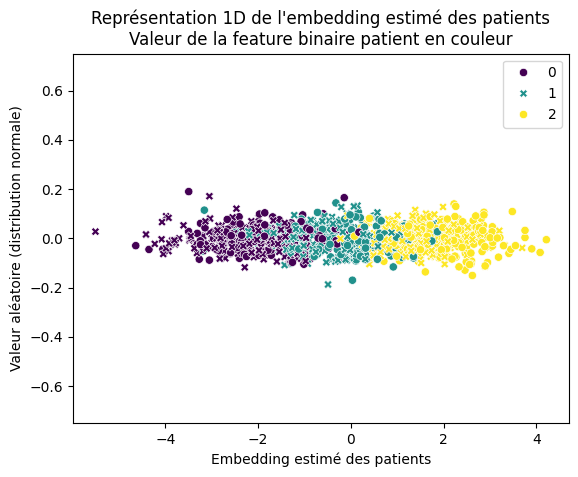

In [422]:
#Visualisation des clusters
sns.set_palette("deep") 

# La couleur représente le degré, c'est-à-dire le nombre de lien qu'a le docteur
sns.scatterplot(x= ef_patient_hat, y= np.random.normal(0, 0.05, size= ef_patient_hat.shape[0],), hue = graph_object.alpha_class,  style=graph_object.sim_patient_D, palette='viridis')
# Ajouter des labels aux axes et au titre
plt.xlabel('Effets fixes estimé des patients')
plt.ylabel('Valeur aléatoire (distribution normale)')
plt.title("Représentation 1D de l'embedding estimé des patients\n"
          "Valeur de la feature binaire patient en couleur")

plt.ylim(-0.75,0.75)
plt.show()

Nous pouvons observer que pour les patients, la variable binaire ne semble pas déterminante lors de la formation de l'embedding.

##  Modèle simplifié

### MF 

In [48]:
graph_object= GraphFormation(
                    n_patients=1000,
                     n_doctors=50,
                     max_number_connections=50,
                    beta_distance_graph = -25,
                    beta_X_p_graph=0,
                     beta_X_d_graph=0,
                     beta_D_p_graph=0,
                     beta_D_d_graph=0,)
graph_object.do_the_graph()
print(f"density of the graph: {graph_object.density*100:.2f}%")

density of the graph: 9.86%


In [63]:
# Training
estimates = MF_NRS.get_estimations_onlydistance(graph_object.df, nb_epochs=40, show_print=0, learning_rate=0.01)
# Recuperation des poids au niveau des embeddings
ef_patient_hat = estimates[1][0]
ef_doctor_hat = estimates[1][1]

# Recuperation des poids pour les beta
#beta_X_p_hat = estimates[1][2]
#beta_X_d_hat = estimates[1][3]
#beta_D_p_hat = estimates[1][4]
#beta_D_d_hat = estimates[1][5]
beta_distance_hat = estimates[1][2]
print(beta_distance_hat)
# Recuperation de l'objet "model"
model = estimates[4]

[-0.11202997]


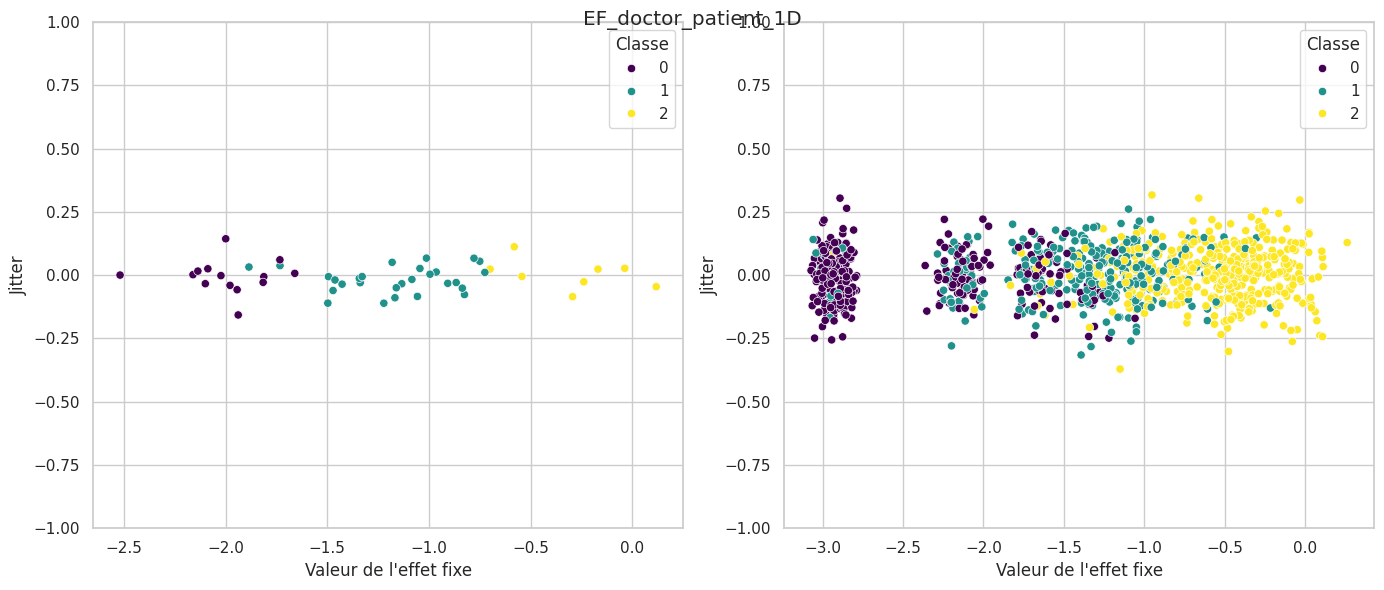

In [64]:
plot_functions.plot_ef_1D(graph_object, ef_patient = ef_patient_hat, ef_doctor = ef_doctor_hat, save=False)

In [65]:
tab_kmeans = metrique.tab_ami_kmeans_inertia(graph_object, ef_patient=ef_patient_hat, ef_doctor = ef_doctor_hat, return_ = True)

    K  Inertia patient  AMI patient  Inertia doctor  AMI doctor
0   2       225.128708     0.369885        5.856719    0.239757
1   3       101.894089     0.411574        2.750584    0.863526
2   4        41.444073     0.372464        1.434707    0.490025
3   5        24.661356     0.348301        0.971247    0.384779
4   6        15.648129     0.273878        0.815595    0.327455
5   7        10.311335     0.257854        0.580978    0.260996
6   8         7.125169     0.233839        0.461879    0.210601
7   9         5.646816     0.205678        0.264320    0.245312
8  10         4.847168     0.199525        0.209756    0.197618


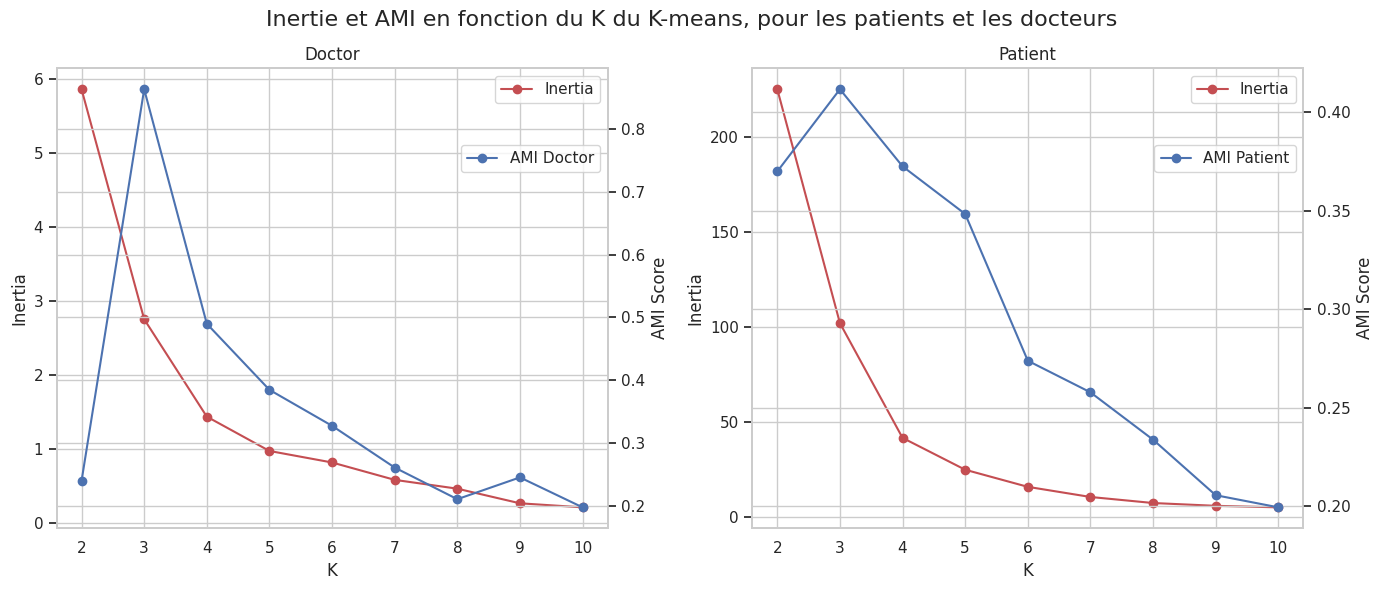

In [66]:
plot_functions.plot_tab_ami_inertia_kmeans(tab_kmeans)

### NRS

In [67]:
graph_object= GraphFormation(
                    n_patients=1000,
                     n_doctors=50,
                     max_number_connections=50,
                    beta_distance_graph = -25,
                    beta_X_p_graph=0,
                     beta_X_d_graph=0,
                     beta_D_p_graph=0,
                     beta_D_d_graph=0,)
graph_object.do_the_graph()
print(f"density of the graph: {graph_object.density*100:.2f}%")

density of the graph: 9.88%


In [68]:
# Training
estimates = MF_NRS.get_estimations_onlydistance(graph_object.df, nb_epochs=40, show_print=0, learning_rate=0.001, algorithm = "NRS")
# Recuperation des poids au niveau des embeddings
ef_patient_hat = estimates[1][0]
ef_doctor_hat = estimates[1][1]

# Recuperation de l'objet "model"
model = estimates[4]

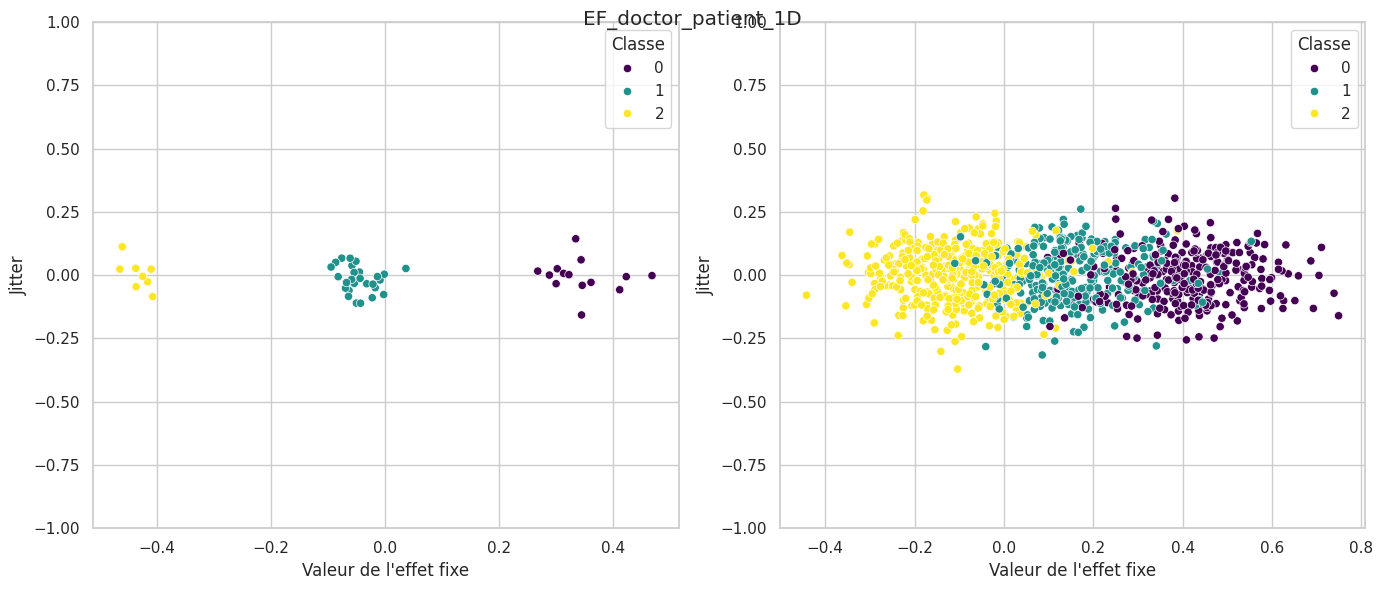

In [69]:
plot_functions.plot_ef_1D(graph_object, ef_patient = ef_patient_hat, ef_doctor = ef_doctor_hat, save=False)

In [73]:
tab_kmeans = metrique.tab_ami_kmeans_inertia(graph_object, ef_patient=ef_patient_hat, ef_doctor = ef_doctor_hat, return_ = True)

    K  Inertia patient  AMI patient  Inertia doctor  AMI doctor
0   2        15.977195     0.443551        1.001610    0.646107
1   3         7.502785     0.566763        0.067971    1.000000
2   4         5.027369     0.430340        0.037375    0.943541
3   5         3.148891     0.372388        0.031138    0.891162
4   6         2.265207     0.352231        0.014084    0.571895
5   7         1.695674     0.308474        0.012357    0.567937
6   8         1.314676     0.282112        0.010007    0.552054
7   9         1.090945     0.255545        0.007361    0.430065
8  10         0.904535     0.242562        0.004897    0.396656


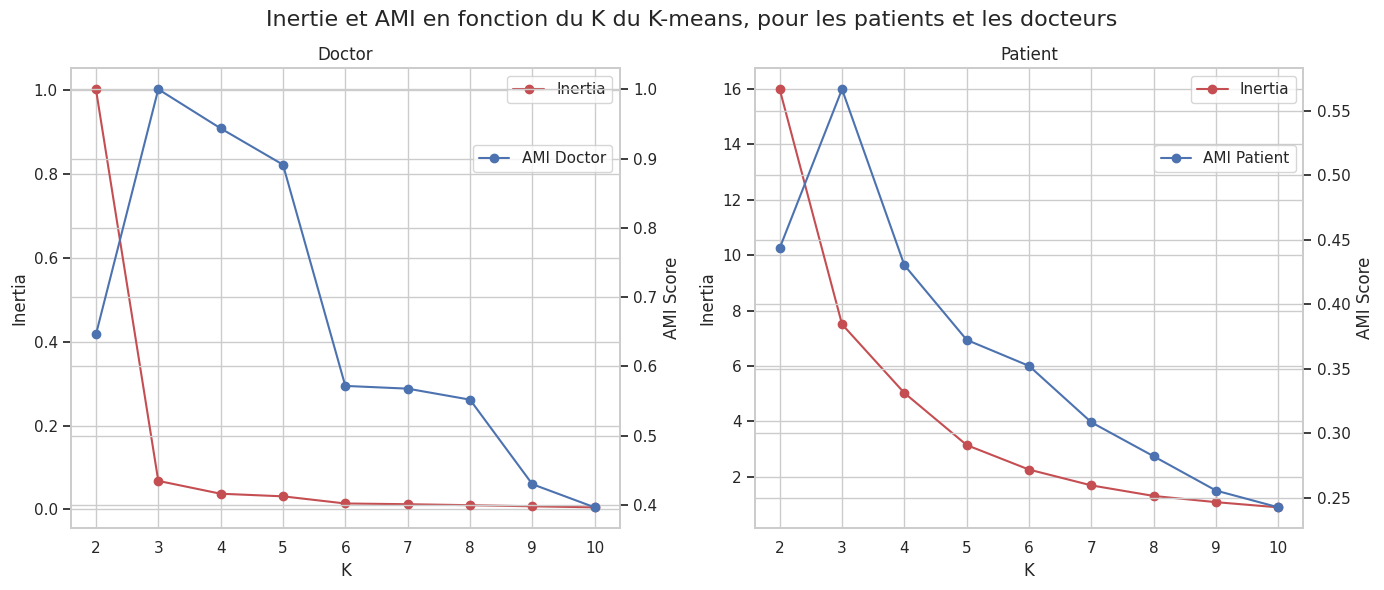

In [74]:
plot_functions.plot_tab_ami_inertia_kmeans(tab_kmeans)

## Panel (Bonus)

### création des données panel

In [455]:
def make_panel_df(T=5, 
                  n_patients=1000,
                    n_doctors=50,
                    max_number_connections=50,
                    z=1.42 ):

    graph_all= graph_formation(
                    n_patients=n_patients,
                     n_doctors=n_doctors,
                     max_number_connections=max_number_connections,
                     z=z )
    panel_df, alpha_graph, psi_graph, alpha_class, psi_class, coor_patients, coor_doctors, D, beta_age_p_star, beta_age_d_star, beta_informed_p_star,\
    beta_skilled_d_star, beta_distance_star, sim_patient_age_normed, sim_doctor_age_normed, sim_patient_informed, sim_doctor_skilled = graph_all
    panel_df['y'] = panel_df['y'].astype("int")
    panel_df['period'] = np.zeros(n_patients*n_doctors)
    # Compile ids
    id_p = np.repeat(range(n_patients), n_doctors)
    id_d = np.tile(range(n_doctors), n_patients)
   
    for t in range(1,T):
        
        A = np.zeros([n_patients, n_doctors], dtype = np.ndarray)
        for i in range(n_patients):
            for j in range(n_doctors):
                if D[i][j] <= z: # if patient i and doctor j are too far away, there is no relation
                    doctor_data = panel_df[panel_df['j']==j]
                    patient_data = panel_df[panel_df['i']==i] 
                    T = alpha_graph[i] + psi_graph[j] + beta_age_p_star * sim_patient_age_normed[i] + beta_age_d_star * sim_doctor_age_normed[j] \
                        + beta_informed_p_star * sim_patient_informed[i] + beta_skilled_d_star * sim_doctor_skilled[j] + beta_distance_star * D[i][j]
                    p = 1 / (1 + np.exp(-T))
                    # P[i][j] = p
                    A[i][j] = np.random.binomial(1, p)
             # Compile relations between doctors and patients
        relation = A.flatten()
        # Merge all columns into a dataframe
        indices = n_doctors * n_patients
        df = pd.DataFrame(data={'i': id_p, 'j': id_d, 'y' : relation, 'age_p': panel_df['age_p'].head(indices) , 'age_d': panel_df['age_d'].head(indices), 
                           'informed_p': panel_df['informed_p'].head(indices), 'skilled_d': panel_df['skilled_d'].head(indices), 'class_p': panel_df['class_p'].head(indices), 'class_d': panel_df['class_d'].head(indices),
                             "distance": panel_df["distance"].head(indices), "ef_p_0": panel_df["ef_p_0"].head(indices), "ef_d_0": panel_df["ef_d_0"].head(indices),    
                                "period":np.ones(n_doctors*n_patients)*t
                            })
            
        panel_df = pd.concat([panel_df, df], ignore_index=True)
    return panel_df
    

In [456]:
panel_df = make_panel_df(T=5)

In [457]:
panel_df['y'] = panel_df['y'].astype("int")
panel_df[(panel_df["j"]==4) & (panel_df['i']==5)]

/opt/conda/lib/python3.12/site-packages/IPython/core/formatters.py:347: FutureWarning: Index.format is deprecated and will be removed in a future version. Convert using index.astype(str) or index.map(formatter) instead.
  return method()


,i,j,y,age_p,age_d,informed_p,skilled_d,class_p,class_d,distance,ef_p_0,ef_d_0,period
254,5,4,0,19,63,0,1,1,0,0.37474,2.0,0.0,0.0
50254,5,4,0,19,63,0,1,1,0,0.37474,2.0,0.0,1.0
100254,5,4,0,19,63,0,1,1,0,0.37474,2.0,0.0,2.0
150254,5,4,0,19,63,0,1,1,0,0.37474,2.0,0.0,3.0
200254,5,4,0,19,63,0,1,1,0,0.37474,2.0,0.0,4.0


In [458]:
panel_df['age_p'] = (panel_df['age_p']-panel_df['age_p'].mean())/panel_df['age_p'].std()
panel_df['age_d'] = (panel_df['age_d']-panel_df['age_d'].mean())/panel_df['age_d'].std()

### Score de prédiction panel

In [157]:
# On prend 80% du dataframe
train_indices = int(panel_df.shape[0]*0.8)
# L'argument drop=True permet de ne pas ajouter l'ancien index comme colonne supplémentaire dans le DataFrame
panel_shuffled = panel_df.sample(frac=1).reset_index(drop=True)
panel_train ,panel_test = panel_shuffled.iloc[:train_indices,:] , panel_shuffled.iloc[train_indices:,:]

In [158]:
estimates = get_estimations(panel_train, nb_epochs=60, initial_weights=None, target_loss=None, show_print=0, regularization="l2")
model_panel = estimates[4]
history_panel = estimates[5]
loss = estimates[0]

/opt/conda/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


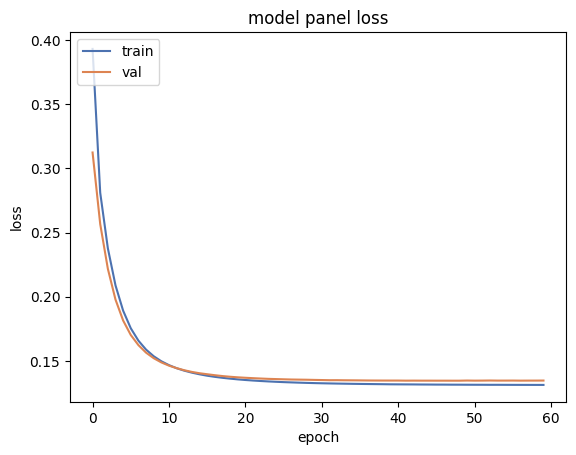

In [159]:
plt.plot(history_panel.history["loss"])
plt.plot(history_panel.history["val_loss"])
plt.title("model panel loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="upper left")
plt.show()

In [160]:
# Drop unwanted columns
X_test = panel_test.drop(['y', 'class_p', 'class_d', 'ef_p_0', 'ef_d_0', 'period'], axis=1)

# Assurez-vous que les colonnes sont dans le bon ordre
input_data = [tf.constant(X_test[col].values.reshape(-1, 1), dtype=tf.float32) for col in X_test.columns]

# Predict
results = model_panel.predict(input_data)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [161]:
y_true = panel_test['y'].values.astype(int)
y_pred =  (results.flatten() > 0.5).astype(int)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
mse = np.sum((results.flatten()-panel_test['y'])**2)/1500
print(f"Mean Squared Error sur l'échantillon de test : {mse}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")

Mean Squared Error sur l'échantillon de test : 1.3863017721104849
Precision: 0.80
Recall: 0.73
F1-score: 0.76


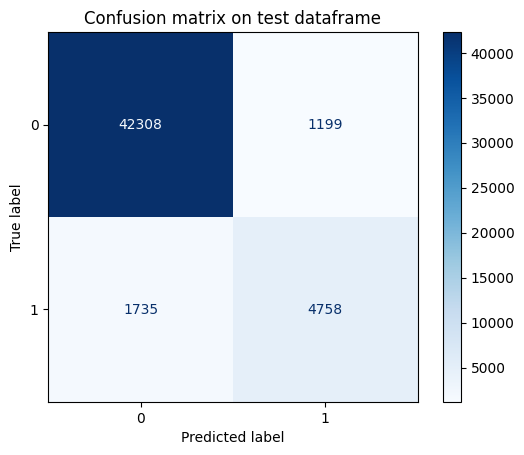

In [162]:
# Calculer la matrice de confusion
cm = confusion_matrix(y_true, y_pred)
# Affiche la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm,)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion matrix on test dataframe")
plt.show()

### estimation des paramètres

In [461]:
estimates = get_estimations(panel_df, nb_epochs=60, initial_weights=None, target_loss=None, show_print=0)
ef_patient = estimates[1][0]
ef_doctor = estimates[1][1]
beta_age_p = estimates[1][2]
beta_age_d = estimates[1][3]
beta_informed_p = estimates[1][4]
beta_skilled_d = estimates[1][5]
beta_distance = estimates[1][6]

In [462]:
print(f"ESTIMATION BETA: age p {beta_age_p}; age d {beta_age_d}; informed {beta_informed_p}; skilled {beta_skilled_d}; distance {beta_distance}")
print(f"ERROR ESTIMATION BETA: age p {beta_age_p-0.2}; age d {beta_age_d-0.2}; informed {beta_informed_p-1}; skilled {beta_skilled_d-1}; distance {beta_distance+20}")

ESTIMATION BETA: age p [0.2120851]; age d [-0.04403578]; informed [1.4291133]; skilled [3.3869033]; distance [-19.916246]
ERROR ESTIMATION BETA: age p [0.0120851]; age d [-0.24403578]; informed [0.42911327]; skilled [2.3869033]; distance [0.08375359]


(array([12.,  8.,  0.,  0.,  8., 10.,  5.,  0.,  1.,  6.]),
 array([-0.60040855, -0.10440449,  0.39159957,  0.88760364,  1.38360763,
         1.87961173,  2.37561584,  2.87161994,  3.36762381,  3.86362791,
         4.35963202]),
 <BarContainer object of 10 artists>)

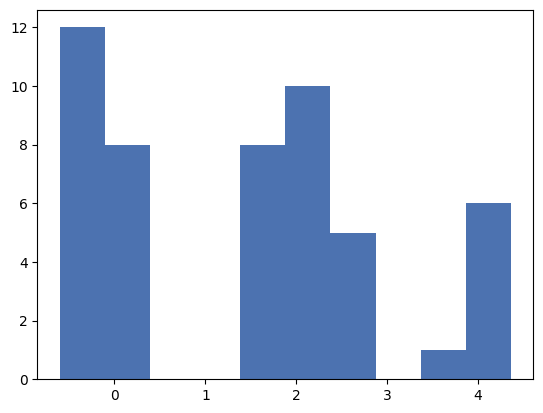

In [472]:
plt.hist(ef_doctor)

(array([ 11.,  79., 140.,  65.,  81., 171.,  51.,  97., 248.,  57.]),
 array([-4.15021038, -3.47245574, -2.79470134, -2.1169467 , -1.43919218,
        -0.76143765, -0.08368311,  0.59407145,  1.27182603,  1.94958055,
         2.62733507]),
 <BarContainer object of 10 artists>)

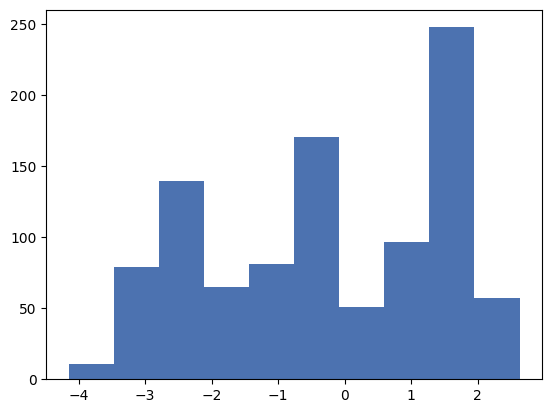

In [473]:
plt.hist(ef_patient)